# mmraz-probe-variations-red-team-20260322-090107

Goal: inspect the temporal probe dataset and validate predictive-accuracy claims in this repo, with the 20260322-090107 red-team examples added to the retraining set.

This notebook does three things:
1. Inspects the explicit/implicit temporal datasets used for probe analysis.
2. Evaluates the saved linear probes (`results/checkpoints/temporal_caa_layer_*.pkl`) on fresh GPT-2 activations.
3. Re-trains layer-wise probes with the 20260322-090107 judged red-team examples appended to the training split, and stores the new MM checkpoints in a separate directory.

In [90]:
from pathlib import Path
import hashlib
import json
import pickle
import re
import warnings

import numpy as np
import pandas as pd
import torch
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from transformers import AutoModelForCausalLM, AutoTokenizer
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 200)


In [91]:
def find_repo_root(start: Path) -> Path:
    p = start.resolve()
    for _ in range(8):
        if (p / 'pyproject.toml').exists() and (p / 'data').exists():
            return p
        p = p.parent
    raise RuntimeError('Could not locate repo root from current working directory.')

ROOT = find_repo_root(Path.cwd())
print('Repo root:', ROOT)

def pick_first_existing(paths):
    for p in paths:
        if p.exists():
            return p
    raise FileNotFoundError('None of these paths exist: ' + str(paths))

explicit_path = pick_first_existing([
    ROOT / 'data/raw/temporal_scope_AB_randomized/temporal_scope_caa.json',
    ROOT / 'data/raw/temporal_scope/temporal_scope_caa.json',
    ROOT / 'data/raw/temporal_scope_caa.json',
])
implicit_path = pick_first_existing([
    ROOT / 'data/raw/temporal_scope_AB_randomized/temporal_scope_implicit.json',
    ROOT / 'data/raw/temporal_scope/temporal_scope_implicit.json',
    ROOT / 'data/raw/temporal_scope_implicit.json',
])
probe_dir = ROOT / 'results/checkpoints'

print('Explicit dataset:', explicit_path)
print('Implicit dataset:', implicit_path)
print('Probe directory:', probe_dir)

Repo root: /Users/michalmraz/code/spar-ai/temporal-awareness
Explicit dataset: /Users/michalmraz/code/spar-ai/temporal-awareness/data/raw/temporal_scope_AB_randomized/temporal_scope_caa.json
Implicit dataset: /Users/michalmraz/code/spar-ai/temporal-awareness/data/raw/temporal_scope_AB_randomized/temporal_scope_implicit.json
Probe directory: /Users/michalmraz/code/spar-ai/temporal-awareness/results/checkpoints


In [92]:
def load_pairs(path: Path):
    data = json.loads(path.read_text())
    if isinstance(data, dict) and 'pairs' in data:
        return data.get('metadata', {}), data['pairs']
    return {}, data

exp_meta, explicit_pairs = load_pairs(explicit_path)
imp_meta, implicit_pairs = load_pairs(implicit_path)

print('Explicit metadata:', exp_meta)
print('Implicit metadata:', imp_meta)
print('\nCounts:')
print('  explicit pairs:', len(explicit_pairs))
print('  implicit pairs:', len(implicit_pairs))

# display(pd.DataFrame(explicit_pairs).head(3))
# display(pd.DataFrame(implicit_pairs).head(3))
display(pd.DataFrame(explicit_pairs))
display(pd.DataFrame(implicit_pairs))

Explicit metadata: {'dimension': 'temporal_scope', 'description': 'CAA-style contrastive pairs for temporal scope steering (immediate ↔ long-term)', 'style': 'caa_question_answer', 'n_pairs': 50, 'contrast': 'immediate/short-term vs long-term/future-oriented thinking', 'rationale': 'Follows actual CAA methodology with scenario-based questions and answer choices'}
Implicit metadata: {'dimension': 'temporal_scope', 'style': 'implicit_markers_only', 'description': 'Temporal scope dataset with NO explicit time words (minutes, years, etc.). Uses only semantic/contextual cues.', 'n_pairs': 50, 'validation': 'Strong test of semantic vs lexical encoding', 'created': '2025-01-26', 'position_randomized': True}

Counts:
  explicit pairs: 50
  implicit pairs: 50


,category,question,immediate,long_term
0,planning,"When deciding on a solution to this problem, y...",(A) What works right now to fix the immediate...,(B) What will create lasting value over the n...
1,planning,The best approach for this project is to:,(B) Get quick results and iterate as problems...,(A) Build a solid foundation that will scale ...
2,planning,"When allocating resources, you should prioritize:",(A) Addressing today's urgent needs,(B) Investing in tomorrow's opportunities
3,planning,"In making this decision, what matters most is:",(B) Solving the current crisis,(A) Preventing future problems
4,planning,The key factor to consider here is:,(A) What delivers immediate impact,(B) What compounds over time
5,decision_making,"When evaluating this option, you should ask:",(B) Does this solve today's problem?,(A) Will this still be valuable in 10 years?
6,decision_making,The most important outcome is:,(A) Getting quick wins now,(B) Building sustainable advantage
7,decision_making,Success means:,(B) Hitting this quarter's targets,(A) Creating generational impact
8,decision_making,The right choice is the one that:,(A) Provides instant gratification,(B) Yields delayed but greater rewards
9,decision_making,You should optimize for:,(B) Short-term gains,(A) Long-term value creation


,question,immediate,long_term,category
0,"When addressing this challenge, we should prio...",(A) Tactical responses that handle the situat...,(B) Strategic frameworks that create institut...,tactical_strategic
1,The most important consideration here is,(B) Operational efficiency and rapid execution,(A) Foundational principles and systemic resi...,operational_foundational
2,Our focus should be on,(A) Reactive measures to address presenting s...,(B) Proactive interventions that prevent root...,reactive_proactive
3,Success means,(B) Meeting deadlines and showing tangible pr...,(A) Building values and creating transformati...,deadlines_values
4,The right approach involves,(A) Triage and damage control,(B) Comprehensive planning and preventive mea...,emergency_preventive
5,We should optimize for,"(B) Speed, agility, and wins","(A) Sustainability, durability, and compound ...",speed_sustainability
6,The key metric is,(A) Direct throughput and output volume,(B) Cumulative impact and sustained performance,throughput_cumulative
7,Resource allocation should emphasize,(B) Firefighting and crisis response capacity,(A) Infrastructure development and capability...,firefighting_infrastructure
8,Decision-making should be guided by,(A) Responsiveness and decisiveness,(B) Reflection and thorough analysis,urgency_patience
9,The right mindset is,(B) Action-oriented and results-driven,(A) Vision-oriented and principle-driven,action_vision


In [93]:
def sha256(path: Path) -> str:
    return hashlib.sha256(path.read_bytes()).hexdigest()

reported_path = ROOT / 'results/probe_validation_results.json'
reported_hashes = {}
if reported_path.exists():
    reported = json.loads(reported_path.read_text())
    datasets = reported.get('datasets', {})
    reported_hashes['explicit'] = datasets.get('explicit_dataset', {}).get('sha256')
    reported_hashes['implicit'] = datasets.get('implicit_dataset', {}).get('sha256')

current_hashes = {
    'explicit': sha256(explicit_path),
    'implicit': sha256(implicit_path),
}

hash_df = pd.DataFrame([
    {
        'dataset': 'explicit',
        'current_sha256': current_hashes['explicit'],
        'reported_sha256': reported_hashes.get('explicit'),
        'match': current_hashes['explicit'] == reported_hashes.get('explicit'),
    },
    {
        'dataset': 'implicit',
        'current_sha256': current_hashes['implicit'],
        'reported_sha256': reported_hashes.get('implicit'),
        'match': current_hashes['implicit'] == reported_hashes.get('implicit'),
    },
])
display(hash_df)

if not hash_df['match'].all():
    print('NOTE: dataset hashes differ from the hashes recorded in results/probe_validation_results.json.')
    print('Exact numeric reproduction may differ if the dataset file has changed.')

,dataset,current_sha256,reported_sha256,match
0,explicit,1e782fe6304cbd7b3460a87bac1d4c78e72519a8aa4ad9...,8c30b3168b61cbce18623bdd6465cfe31ab7c5c54f309f...,False
1,implicit,9eeaec55cd10e2f72102c6758d0f6682f543aa2ce83591...,8d34212a4cb19f661bc30b1be31d5b691d72e5decbd496...,False


NOTE: dataset hashes differ from the hashes recorded in results/probe_validation_results.json.
Exact numeric reproduction may differ if the dataset file has changed.


In [94]:
def extract_option_letter(option_text):
    match = re.search(r'\(([ABab])\)', option_text or '')
    return match.group(1).upper() if match else None


def strip_option_label(option_text):
    return re.sub(r'^\s*\([ABab]\)\s*', '', option_text or '').strip()


def get_pair_option_payload(pair):
    immediate_letter = extract_option_letter(pair['immediate'])
    long_term_letter = extract_option_letter(pair['long_term'])

    if immediate_letter and long_term_letter and immediate_letter != long_term_letter:
        option_a_text = pair['immediate'] if immediate_letter == 'A' else pair['long_term']
        option_b_text = pair['immediate'] if immediate_letter == 'B' else pair['long_term']
    else:
        option_a_text = pair['immediate']
        option_b_text = pair['long_term']

    return {
        'option_a_text': option_a_text,
        'option_b_text': option_b_text,
        'immediate_text': pair['immediate'],
        'long_term_text': pair['long_term'],
    }


def build_probe_prompt(option_a_text, option_b_text):
    option_a_text = strip_option_label(option_a_text)
    option_b_text = strip_option_label(option_b_text)
    return (
        'Options:\\n'
        f'{option_a_text}\\n'
        f'{option_b_text}\\n'
        'Answer:\\n'
    )


def build_teacher_forced_examples_from_pairs(pairs):
    examples = []
    labels = []

    for pair in pairs:
        option_payload = get_pair_option_payload(pair)
        prompt = build_probe_prompt(
            option_payload['option_a_text'],
            option_payload['option_b_text'],
        )

        examples.append({
            'prompt': prompt,
            'continuation': strip_option_label(option_payload['immediate_text']),
            'label': 0,
        })
        labels.append(0)

        examples.append({
            'prompt': prompt,
            'continuation': strip_option_label(option_payload['long_term_text']),
            'label': 1,
        })
        labels.append(1)

    return examples, np.array(labels, dtype=np.int64)


explicit_examples, y_exp = build_teacher_forced_examples_from_pairs(explicit_pairs)
implicit_examples, y_imp = build_teacher_forced_examples_from_pairs(implicit_pairs)

print('Explicit samples:', len(y_exp), '| class balance:', np.bincount(y_exp))
print('Implicit samples:', len(y_imp), '| class balance:', np.bincount(y_imp))
print('Probe prompt format:', repr(explicit_examples[0]['prompt']))
print('Example short-term continuation:', repr(explicit_examples[0]['continuation']))


Explicit samples: 100 | class balance: [50 50]
Implicit samples: 100 | class balance: [50 50]
Probe prompt format: 'Options:\\nWhat works right now to fix the immediate issue\\nWhat will create lasting value over the next decade\\nAnswer:\\n'
Example short-term continuation: 'What works right now to fix the immediate issue'


In [95]:
MODEL_NAME = 'gpt2'
device = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
print('Device:', device)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(device)
model.eval()
n_layers = model.config.n_layer
print('Loaded', MODEL_NAME, '| n_layers =', n_layers, '| d_model =', model.config.n_embd)

Device: cpu
Loaded gpt2 | n_layers = 12 | d_model = 768


In [96]:
@torch.no_grad()
def extract_mean_answer_token_activations(examples, batch_size=16):
    by_layer = {layer: [] for layer in range(n_layers)}
    pad_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else tokenizer.eos_token_id

    for start in range(0, len(examples), batch_size):
        batch_examples = examples[start:start + batch_size]
        prompt_ids_batch = []
        continuation_ids_batch = []
        seq_lengths = []
        answer_spans = []

        for example in batch_examples:
            prompt_ids = tokenizer(
                example['prompt'],
                add_special_tokens=False,
                return_tensors='pt',
            )['input_ids'][0]
            continuation_ids = tokenizer(
                example['continuation'],
                add_special_tokens=False,
                return_tensors='pt',
            )['input_ids'][0]
            if continuation_ids.numel() == 0:
                raise ValueError(f"Empty continuation for probe example: {example!r}")

            prompt_ids_batch.append(prompt_ids)
            continuation_ids_batch.append(continuation_ids)
            seq_lengths.append(int(prompt_ids.shape[0] + continuation_ids.shape[0]))

        max_seq_len = max(seq_lengths)
        input_ids = torch.full((len(batch_examples), max_seq_len), pad_id, dtype=torch.long)
        attention_mask = torch.zeros((len(batch_examples), max_seq_len), dtype=torch.long)

        for row_idx, (prompt_ids, continuation_ids) in enumerate(zip(prompt_ids_batch, continuation_ids_batch)):
            seq = torch.cat([prompt_ids, continuation_ids], dim=0)
            seq_len = int(seq.shape[0])
            answer_start = int(prompt_ids.shape[0])
            answer_end = seq_len

            input_ids[row_idx, :seq_len] = seq
            attention_mask[row_idx, :seq_len] = 1
            answer_spans.append((answer_start, answer_end))

        batch = {
            'input_ids': input_ids.to(device),
            'attention_mask': attention_mask.to(device),
        }
        out = model(**batch, output_hidden_states=True)

        for layer in range(n_layers):
            hs = out.hidden_states[layer + 1]
            pooled_rows = []
            for row_idx, (answer_start, answer_end) in enumerate(answer_spans):
                pooled = hs[row_idx, answer_start:answer_end, :].mean(dim=0)
                pooled_rows.append(pooled.detach().cpu().numpy())
            by_layer[layer].append(np.stack(pooled_rows, axis=0))

    for layer in by_layer:
        by_layer[layer] = np.concatenate(by_layer[layer], axis=0)

    return by_layer


X_exp = extract_mean_answer_token_activations(explicit_examples, batch_size=16)
X_imp = extract_mean_answer_token_activations(implicit_examples, batch_size=16)

print('Activation shapes:')
print('  explicit layer 0:', X_exp[0].shape)
print('  implicit layer 0:', X_imp[0].shape)


Activation shapes:
  explicit layer 0: (100, 768)
  implicit layer 0: (100, 768)


In [97]:
RED_TEAM_RUN_ID = '20260322-090107'
PROBE_FORMAT_SLUG = 'options_answer_stripped_mean_answer_tokens'
ORIGINAL_MM_FILENAME_TEMPLATE = 'mmraz_gpt2_explicit_expanded_options_answer_mm_probe_layer_{layer}.json'
AUGMENTED_MM_FILENAME_TEMPLATE = 'mmraz_gpt2_explicit_expanded_plus_redteam_options_answer_mm_probe_layer_{layer}.json'
RED_TEAM_ONLY_MM_FILENAME_TEMPLATE = 'mmraz_gpt2_redteam_only_options_answer_mm_probe_layer_{layer}.json'

red_team_run_dir = ROOT / 'out/mmraz_intertemporal/adversarial_red_teaming/runs' / RED_TEAM_RUN_ID
stripped_red_team_dataset_path = red_team_run_dir / 'probe_dataset_stripped.jsonl'
original_mm_probe_dir = ROOT / 'results/checkpoints' / ('mmraz_probe_variations_original_' + PROBE_FORMAT_SLUG)
red_team_augmented_probe_dir = ROOT / 'results/checkpoints' / ('mmraz_probe_variations_red_team_augmented_' + RED_TEAM_RUN_ID + '_' + PROBE_FORMAT_SLUG)
red_team_only_mm_probe_dir = ROOT / 'results/checkpoints' / ('mmraz_probe_variations_red_team_only_' + RED_TEAM_RUN_ID + '_' + PROBE_FORMAT_SLUG)

for checkpoint_dir in [original_mm_probe_dir, red_team_augmented_probe_dir, red_team_only_mm_probe_dir]:
    checkpoint_dir.mkdir(parents=True, exist_ok=True)


def load_stripped_red_team_examples(dataset_path):
    examples = []
    labels = []
    rows = []

    if not dataset_path.exists():
        raise FileNotFoundError(
            'Missing stripped red-team dataset: ' + str(dataset_path) +
            '. Run scripts/mmraz_intertemporal/build_stripped_red_team_probe_dataset.py first.'
        )

    for line in dataset_path.read_text(encoding='utf-8').splitlines():
        if not line.strip():
            continue
        payload = json.loads(line)
        label_text = payload['judge_label']
        if label_text == 'short_term':
            label = 0
        elif label_text == 'long_term':
            label = 1
        else:
            raise ValueError('Unexpected judge_label: ' + repr(label_text))

        examples.append({
            'prompt': payload['probe_prompt'],
            'continuation': payload['probe_completion'],
            'label': label,
        })
        labels.append(label)
        rows.append({
            'candidate_id': payload['candidate_id'],
            'round_idx': payload['round_idx'],
            'judge_label': payload['judge_label'],
            'probe_label': payload['probe_label'],
            'is_adversarial_success': payload['is_adversarial_success'],
            'chosen_option_letter': payload['chosen_option_letter'],
            'probe_completion': payload['probe_completion'],
            'completion_prefix_matches_option': payload['completion_prefix_matches_option'],
        })

    return examples, np.array(labels, dtype=np.int64), pd.DataFrame(rows)


red_team_examples, y_redteam, red_team_df = load_stripped_red_team_examples(stripped_red_team_dataset_path)
X_redteam = extract_mean_answer_token_activations(red_team_examples, batch_size=16)

print('Red-team run:', RED_TEAM_RUN_ID)
print('Stripped red-team dataset:', stripped_red_team_dataset_path)
print('Probe format slug:', PROBE_FORMAT_SLUG)
print('Red-team examples:', len(y_redteam), '| class balance:', np.bincount(y_redteam))
print('Original MM checkpoint dir:', original_mm_probe_dir)
print('Augmented MM checkpoint dir:', red_team_augmented_probe_dir)
print('Red-team-only MM checkpoint dir:', red_team_only_mm_probe_dir)
print('Saved LogisticRegression checkpoints were trained on the legacy single-option format; treat their scores below as out-of-format reference only.')
display(red_team_df.groupby(['judge_label', 'is_adversarial_success']).size().rename('n_examples').reset_index())

probe_paths = {layer: probe_dir / f'temporal_caa_layer_{layer}_probe.pkl' for layer in range(n_layers)}
missing = [layer for layer, p in probe_paths.items() if not p.exists()]
if missing:
    raise FileNotFoundError(f'Missing probe files for layers: {missing}')

indices = np.arange(len(y_exp))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42, stratify=y_exp)

rows = []
for layer in range(n_layers):
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        probe = pickle.load(open(probe_paths[layer], 'rb'))

    rows.append({
        'layer': layer,
        'saved_probe_explicit_test_acc': probe.score(X_exp[layer][test_idx], y_exp[test_idx]),
        'saved_probe_explicit_full_acc': probe.score(X_exp[layer], y_exp),
        'saved_probe_implicit_acc': probe.score(X_imp[layer], y_imp),
    })

saved_eval_df = pd.DataFrame(rows).sort_values('layer').reset_index(drop=True)
display(saved_eval_df)

best_test = saved_eval_df.loc[saved_eval_df['saved_probe_explicit_test_acc'].idxmax()]
best_implicit = saved_eval_df.loc[saved_eval_df['saved_probe_implicit_acc'].idxmax()]
print('Best saved-probe explicit TEST layer:', int(best_test.layer), 'acc=', round(float(best_test.saved_probe_explicit_test_acc), 4))
print('Best saved-probe implicit layer:', int(best_implicit.layer), 'acc=', round(float(best_implicit.saved_probe_implicit_acc), 4))


Red-team run: 20260322-090107
Stripped red-team dataset: /Users/michalmraz/code/spar-ai/temporal-awareness/out/mmraz_intertemporal/adversarial_red_teaming/runs/20260322-090107/probe_dataset_stripped.jsonl
Probe format slug: options_answer_stripped_mean_answer_tokens
Red-team examples: 190 | class balance: [98 92]
Original MM checkpoint dir: /Users/michalmraz/code/spar-ai/temporal-awareness/results/checkpoints/mmraz_probe_variations_original_options_answer_stripped_mean_answer_tokens
Augmented MM checkpoint dir: /Users/michalmraz/code/spar-ai/temporal-awareness/results/checkpoints/mmraz_probe_variations_red_team_augmented_20260322-090107_options_answer_stripped_mean_answer_tokens
Red-team-only MM checkpoint dir: /Users/michalmraz/code/spar-ai/temporal-awareness/results/checkpoints/mmraz_probe_variations_red_team_only_20260322-090107_options_answer_stripped_mean_answer_tokens
Saved LogisticRegression checkpoints were trained on the legacy single-option format; treat their scores below as

,judge_label,is_adversarial_success,n_examples
0,long_term,True,92
1,short_term,False,98


,layer,saved_probe_explicit_test_acc,saved_probe_explicit_full_acc,saved_probe_implicit_acc
0,0,0.75,0.75,0.72
1,1,0.80,0.86,0.62
2,2,0.85,0.89,0.67
3,3,0.90,0.90,0.69
4,4,0.90,0.90,0.70
5,5,0.85,0.80,0.52
6,6,0.80,0.85,0.62
7,7,0.80,0.86,0.65
8,8,0.80,0.74,0.53
9,9,0.55,0.65,0.54


Best saved-probe explicit TEST layer: 3 acc= 0.9
Best saved-probe implicit layer: 0 acc= 0.72


In [98]:
# Metric definitions used below:
# - explicit_test_acc: accuracy on the held-out 20% split from the explicit dataset
#   (train_idx/test_idx split of explicit samples only).
# - implicit_acc: accuracy on the full implicit dataset (a separate distribution,
#   not used for fitting), used as a generalization check.

def train_mm_probe(X_train, y_train):
    """Train mean-mass (difference-in-means) probe direction."""
    mu0 = X_train[y_train == 0].mean(axis=0)
    mu1 = X_train[y_train == 1].mean(axis=0)
    direction = mu1 - mu0
    return direction


def mm_predict(X, direction):
    scores = X @ direction
    y_pred = (scores > 0).astype(np.int64)
    return y_pred, scores


def fit_whitener(X_train, reg=1e-2):
    """Fit training-only whitener with regularized covariance.

    Returns both:
    - precision (Sigma^{-1}) for Mahalanobis-style scoring
    - inv_sqrt (Sigma^{-1/2}) for whitening activations before LogisticRegression
    """
    mean_train = X_train.mean(axis=0)
    Xc = X_train - mean_train

    cov = np.cov(Xc, rowvar=False, bias=False)
    avg_var = float(np.trace(cov) / cov.shape[0]) if cov.shape[0] > 0 else 1.0
    cov_reg = cov + (reg * avg_var) * np.eye(cov.shape[0], dtype=cov.dtype)

    precision = np.linalg.pinv(cov_reg)

    eigvals, eigvecs = np.linalg.eigh(cov_reg)
    eigvals = np.clip(eigvals, 1e-12, None)
    inv_sqrt = eigvecs @ np.diag(1.0 / np.sqrt(eigvals)) @ eigvecs.T

    try:
        cond = float(np.linalg.cond(cov_reg))
    except Exception:
        cond = float('nan')

    return {
        'mean_train': mean_train,
        'cov': cov,
        'cov_reg': cov_reg,
        'precision': precision,
        'inv_sqrt': inv_sqrt,
        'reg': reg,
        'cov_reg_condition_number': cond,
    }


def apply_whitener(X, whitener):
    Xc = X - whitener['mean_train']
    return Xc @ whitener['inv_sqrt']


def train_whitened_mm_probe(X_train, y_train, reg=1e-2):
    """Train whitened MM probe.

    Score rule requested:
        score(x) = (x - mean_train)^T Sigma^{-1} (mu1 - mu0)
    predict class 1 if score > 0 else class 0.
    """
    mu0 = X_train[y_train == 0].mean(axis=0)
    mu1 = X_train[y_train == 1].mean(axis=0)
    mm_direction = mu1 - mu0

    whitener = fit_whitener(X_train, reg=reg)
    effective_direction = whitener['precision'] @ mm_direction

    return {
        'mean_train': whitener['mean_train'],
        'mm_direction': mm_direction,
        'effective_direction': effective_direction,
        'precision': whitener['precision'],
        'cov_reg': whitener['cov_reg'],
        'reg': whitener['reg'],
        'cov_reg_condition_number': whitener['cov_reg_condition_number'],
    }


def whitened_mm_predict(X, model):
    Xc = X - model['mean_train']
    scores = Xc @ model['effective_direction']
    y_pred = (scores > 0).astype(np.int64)
    return y_pred, scores


retrain_rows = []
wlr_rows = []
mm_rows = []
wmm_rows = []
cosine_rows = []

whiten_reg = 1e-2
print('Base explicit train size:', len(train_idx), '| red-team examples added:', len(y_redteam), '| augmented train size:', len(train_idx) + len(y_redteam))

for layer in range(n_layers):
    X_train_base = X_exp[layer][train_idx]
    y_train_base = y_exp[train_idx]
    X_train = np.concatenate([X_train_base, X_redteam[layer]], axis=0)
    y_train = np.concatenate([y_train_base, y_redteam], axis=0)
    X_test = X_exp[layer][test_idx]
    y_test = y_exp[test_idx]

    # LogisticRegression probe (raw activations)
    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_train, y_train)
    retrain_rows.append({
        'layer': layer,
        'retrained_explicit_test_acc': clf.score(X_test, y_test),
        'retrained_implicit_acc': clf.score(X_imp[layer], y_imp),
    })

    # Whitened LogisticRegression probe (train+infer on whitened activations)
    whitener = fit_whitener(X_train, reg=whiten_reg)
    X_train_w = apply_whitener(X_train, whitener)
    X_test_w = apply_whitener(X_test, whitener)
    X_imp_w = apply_whitener(X_imp[layer], whitener)

    clf_w = LogisticRegression(max_iter=1000, random_state=42)
    clf_w.fit(X_train_w, y_train)
    wlr_rows.append({
        'layer': layer,
        'wlr_explicit_test_acc': clf_w.score(X_test_w, y_test),
        'wlr_implicit_acc': clf_w.score(X_imp_w, y_imp),
        'wlr_cov_reg_condition_number': whitener['cov_reg_condition_number'],
        'wlr_reg': float(whiten_reg),
    })

    # Mean-mass (difference-in-means) probe
    mm_direction = train_mm_probe(X_train, y_train)
    mm_pred_test, _ = mm_predict(X_test, mm_direction)
    mm_pred_implicit, _ = mm_predict(X_imp[layer], mm_direction)

    mm_rows.append({
        'layer': layer,
        'mm_explicit_test_acc': float((mm_pred_test == y_test).mean()),
        'mm_implicit_acc': float((mm_pred_implicit == y_imp).mean()),
        'mm_direction_norm': float(np.linalg.norm(mm_direction)),
    })

    # Whitened MM probe
    wmm_model = train_whitened_mm_probe(X_train, y_train, reg=whiten_reg)
    wmm_pred_test, _ = whitened_mm_predict(X_test, wmm_model)
    wmm_pred_implicit, _ = whitened_mm_predict(X_imp[layer], wmm_model)

    wmm_rows.append({
        'layer': layer,
        'wmm_explicit_test_acc': float((wmm_pred_test == y_test).mean()),
        'wmm_implicit_acc': float((wmm_pred_implicit == y_imp).mean()),
        'wmm_effective_direction_norm': float(np.linalg.norm(wmm_model['effective_direction'])),
        'wmm_cov_reg_condition_number': wmm_model['cov_reg_condition_number'],
        'wmm_reg': float(whiten_reg),
    })

    # Geometry comparisons
    w_lr = clf.coef_.ravel()
    eff_dir = wmm_model['effective_direction']

    denom_mm = (np.linalg.norm(w_lr) * np.linalg.norm(mm_direction)) + 1e-12
    denom_wmm = (np.linalg.norm(w_lr) * np.linalg.norm(eff_dir)) + 1e-12
    cos_lr_vs_mm = float(np.dot(w_lr, mm_direction) / denom_mm)
    cos_lr_vs_wmm = float(np.dot(w_lr, eff_dir) / denom_wmm)

    cosine_rows.append({
        'layer': layer,
        'cosine_lr_vs_mm': cos_lr_vs_mm,
        'cosine_lr_vs_wmm': cos_lr_vs_wmm,
    })

retrain_df = pd.DataFrame(retrain_rows).sort_values('layer').reset_index(drop=True)
wlr_df = pd.DataFrame(wlr_rows).sort_values('layer').reset_index(drop=True)
mm_df = pd.DataFrame(mm_rows).sort_values('layer').reset_index(drop=True)
wmm_df = pd.DataFrame(wmm_rows).sort_values('layer').reset_index(drop=True)
cosine_df = pd.DataFrame(cosine_rows).sort_values('layer').reset_index(drop=True)

display(retrain_df)
display(wlr_df)
display(mm_df)
display(wmm_df)
display(cosine_df)

comparison = (
    saved_eval_df
    .merge(retrain_df, on='layer', how='inner')
    .merge(wlr_df[['layer', 'wlr_explicit_test_acc', 'wlr_implicit_acc']], on='layer', how='inner')
    .merge(mm_df[['layer', 'mm_explicit_test_acc', 'mm_implicit_acc']], on='layer', how='inner')
    .merge(wmm_df[['layer', 'wmm_explicit_test_acc', 'wmm_implicit_acc']], on='layer', how='inner')
)
display(comparison)

best_lr_exp = retrain_df.loc[retrain_df['retrained_explicit_test_acc'].idxmax()]
best_lr_imp = retrain_df.loc[retrain_df['retrained_implicit_acc'].idxmax()]
best_wlr_exp = wlr_df.loc[wlr_df['wlr_explicit_test_acc'].idxmax()]
best_wlr_imp = wlr_df.loc[wlr_df['wlr_implicit_acc'].idxmax()]
best_mm_exp = mm_df.loc[mm_df['mm_explicit_test_acc'].idxmax()]
best_mm_imp = mm_df.loc[mm_df['mm_implicit_acc'].idxmax()]
best_wmm_exp = wmm_df.loc[wmm_df['wmm_explicit_test_acc'].idxmax()]
best_wmm_imp = wmm_df.loc[wmm_df['wmm_implicit_acc'].idxmax()]

print('Best LR explicit TEST layer:', int(best_lr_exp.layer), 'acc=', round(float(best_lr_exp.retrained_explicit_test_acc), 4))
print('Best LR implicit layer:     ', int(best_lr_imp.layer), 'acc=', round(float(best_lr_imp.retrained_implicit_acc), 4))
print('Best WLR explicit TEST layer:', int(best_wlr_exp.layer), 'acc=', round(float(best_wlr_exp.wlr_explicit_test_acc), 4))
print('Best WLR implicit layer:     ', int(best_wlr_imp.layer), 'acc=', round(float(best_wlr_imp.wlr_implicit_acc), 4))
print('Best MM explicit TEST layer: ', int(best_mm_exp.layer), 'acc=', round(float(best_mm_exp.mm_explicit_test_acc), 4))
print('Best MM implicit layer:      ', int(best_mm_imp.layer), 'acc=', round(float(best_mm_imp.mm_implicit_acc), 4))
print('Best WMM explicit TEST layer:', int(best_wmm_exp.layer), 'acc=', round(float(best_wmm_exp.wmm_explicit_test_acc), 4))
print('Best WMM implicit layer:     ', int(best_wmm_imp.layer), 'acc=', round(float(best_wmm_imp.wmm_implicit_acc), 4))



Base explicit train size: 80 | red-team examples added: 190 | augmented train size: 270


/Users/michalmraz/opt/anaconda3/envs/temporal-awareness-venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,layer,retrained_explicit_test_acc,retrained_implicit_acc
0,0,0.80,0.69
1,1,0.90,0.69
2,2,0.90,0.65
3,3,0.85,0.70
4,4,0.90,0.72
5,5,0.80,0.67
6,6,0.80,0.66
7,7,0.80,0.61
8,8,0.85,0.63
9,9,0.85,0.61


,layer,wlr_explicit_test_acc,wlr_implicit_acc,wlr_cov_reg_condition_number,wlr_reg
0,0,0.70,0.67,23343.434084,0.01
1,1,0.80,0.69,22706.943235,0.01
2,2,0.80,0.66,22087.477318,0.01
3,3,0.85,0.64,22664.820741,0.01
4,4,0.95,0.67,22082.149818,0.01
5,5,0.85,0.66,23841.075893,0.01
6,6,0.90,0.60,24853.609773,0.01
7,7,0.75,0.66,21145.409060,0.01
8,8,0.80,0.68,22845.767168,0.01
9,9,0.70,0.64,20223.199476,0.01


,layer,mm_explicit_test_acc,mm_implicit_acc,mm_direction_norm
0,0,0.85,0.70,3.924937
1,1,0.65,0.56,4.521888
2,2,0.55,0.52,5.305404
3,3,0.90,0.71,6.330467
4,4,0.60,0.56,7.140823
5,5,0.90,0.71,8.471503
6,6,0.50,0.51,10.453291
7,7,0.70,0.59,13.328754
8,8,0.50,0.50,15.536815
9,9,0.50,0.50,19.687950


,layer,wmm_explicit_test_acc,wmm_implicit_acc,wmm_effective_direction_norm,wmm_cov_reg_condition_number,wmm_reg
0,0,0.70,0.70,4.048631,23343.434084,0.01
1,1,0.75,0.69,3.491767,22706.943235,0.01
2,2,0.80,0.65,3.123034,22087.477318,0.01
3,3,0.85,0.65,2.599847,22664.820741,0.01
4,4,0.95,0.67,2.203133,22082.149818,0.01
5,5,0.85,0.66,1.900625,23841.075893,0.01
6,6,0.90,0.63,1.571389,24853.609773,0.01
7,7,0.75,0.67,1.272131,21145.409060,0.01
8,8,0.80,0.67,1.117768,22845.767168,0.01
9,9,0.70,0.63,0.940543,20223.199476,0.01


,layer,cosine_lr_vs_mm,cosine_lr_vs_wmm
0,0,0.668883,0.627414
1,1,0.661813,0.619305
2,2,0.639176,0.613249
3,3,0.643297,0.605265
4,4,0.647456,0.638534
5,5,0.618448,0.648662
6,6,0.569432,0.687403
7,7,0.543578,0.698887
8,8,0.497422,0.730554
9,9,0.440165,0.775870


,layer,saved_probe_explicit_test_acc,saved_probe_explicit_full_acc,saved_probe_implicit_acc,retrained_explicit_test_acc,retrained_implicit_acc,wlr_explicit_test_acc,wlr_implicit_acc,mm_explicit_test_acc,mm_implicit_acc,wmm_explicit_test_acc,wmm_implicit_acc
0,0,0.75,0.75,0.72,0.80,0.69,0.70,0.67,0.85,0.70,0.70,0.70
1,1,0.80,0.86,0.62,0.90,0.69,0.80,0.69,0.65,0.56,0.75,0.69
2,2,0.85,0.89,0.67,0.90,0.65,0.80,0.66,0.55,0.52,0.80,0.65
3,3,0.90,0.90,0.69,0.85,0.70,0.85,0.64,0.90,0.71,0.85,0.65
4,4,0.90,0.90,0.70,0.90,0.72,0.95,0.67,0.60,0.56,0.95,0.67
5,5,0.85,0.80,0.52,0.80,0.67,0.85,0.66,0.90,0.71,0.85,0.66
6,6,0.80,0.85,0.62,0.80,0.66,0.90,0.60,0.50,0.51,0.90,0.63
7,7,0.80,0.86,0.65,0.80,0.61,0.75,0.66,0.70,0.59,0.75,0.67
8,8,0.80,0.74,0.53,0.85,0.63,0.80,0.68,0.50,0.50,0.80,0.67
9,9,0.55,0.65,0.54,0.85,0.61,0.70,0.64,0.50,0.50,0.70,0.63


Best LR explicit TEST layer: 1 acc= 0.9
Best LR implicit layer:      4 acc= 0.72
Best WLR explicit TEST layer: 4 acc= 0.95
Best WLR implicit layer:      1 acc= 0.69
Best MM explicit TEST layer:  3 acc= 0.9
Best MM implicit layer:       3 acc= 0.71
Best WMM explicit TEST layer: 4 acc= 0.95
Best WMM implicit layer:      0 acc= 0.7


Claimed (repo README):
  Layer 8 train/explicit peak ~ 0.925
  Layer 6 test/implicit ~ 0.84

Measured with saved probes on current dataset files:
  Layer 8 explicit test acc = 0.8
  Layer 6 implicit acc      = 0.62


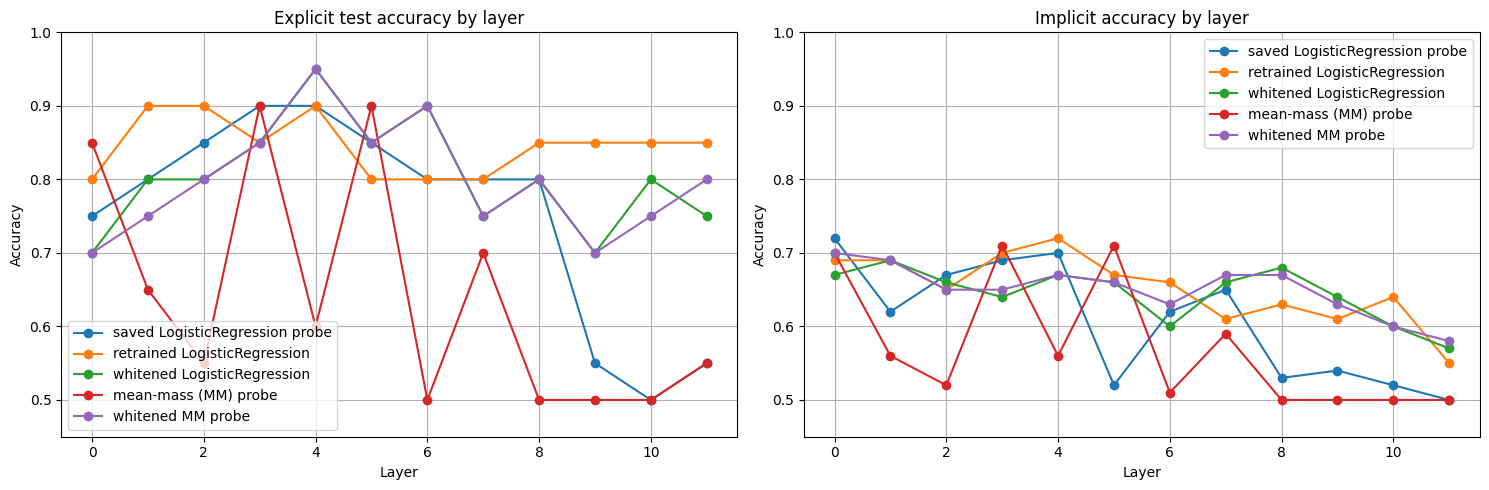

In [99]:
claimed_train_peak_layer = 8
claimed_train_peak_acc = 0.925
claimed_test_peak_layer = 6
claimed_test_peak_acc = 0.84

actual_saved_l8 = float(saved_eval_df.loc[saved_eval_df.layer == claimed_train_peak_layer, 'saved_probe_explicit_test_acc'].iloc[0])
actual_saved_l6 = float(saved_eval_df.loc[saved_eval_df.layer == claimed_test_peak_layer, 'saved_probe_implicit_acc'].iloc[0])

print('Claimed (repo README):')
print('  Layer 8 train/explicit peak ~', claimed_train_peak_acc)
print('  Layer 6 test/implicit ~', claimed_test_peak_acc)
print('\nMeasured with saved probes on current dataset files:')
print('  Layer 8 explicit test acc =', round(actual_saved_l8, 4))
print('  Layer 6 implicit acc      =', round(actual_saved_l6, 4))

fig, ax = plt.subplots(1, 2, figsize=(15, 5.0))

# Explicit test split
ax[0].plot(saved_eval_df.layer, saved_eval_df.saved_probe_explicit_test_acc, marker='o', label='saved LogisticRegression probe')
ax[0].plot(retrain_df.layer, retrain_df.retrained_explicit_test_acc, marker='o', label='retrained LogisticRegression')
ax[0].plot(wlr_df.layer, wlr_df.wlr_explicit_test_acc, marker='o', label='whitened LogisticRegression')
ax[0].plot(mm_df.layer, mm_df.mm_explicit_test_acc, marker='o', label='mean-mass (MM) probe')
ax[0].plot(wmm_df.layer, wmm_df.wmm_explicit_test_acc, marker='o', label='whitened MM probe')
# ax[0].axhline(claimed_train_peak_acc, linestyle='--', color='gray', label='claimed 0.925')
ax[0].set_title('Explicit test accuracy by layer')
ax[0].set_xlabel('Layer')
ax[0].set_ylabel('Accuracy')
ax[0].set_ylim(0.45, 1.0)
ax[0].grid()
ax[0].legend(loc='lower left')

# Implicit dataset
ax[1].plot(saved_eval_df.layer, saved_eval_df.saved_probe_implicit_acc, marker='o', label='saved LogisticRegression probe')
ax[1].plot(retrain_df.layer, retrain_df.retrained_implicit_acc, marker='o', label='retrained LogisticRegression')
ax[1].plot(wlr_df.layer, wlr_df.wlr_implicit_acc, marker='o', label='whitened LogisticRegression')
ax[1].plot(mm_df.layer, mm_df.mm_implicit_acc, marker='o', label='mean-mass (MM) probe')
ax[1].plot(wmm_df.layer, wmm_df.wmm_implicit_acc, marker='o', label='whitened MM probe')
# ax[1].axhline(claimed_test_peak_acc, linestyle='--', color='gray', label='claimed 0.84')
ax[1].set_title('Implicit accuracy by layer')
ax[1].set_xlabel('Layer')
ax[1].set_ylabel('Accuracy')
ax[1].set_ylim(0.45, 1.0)
ax[1].grid()
ax[1].legend()

plt.tight_layout()
plt.show()



## Expanded Dataset Evaluation (500 explicit / 300 implicit)

This section repeats the same methodology as above on:
- `temporal_scope_explicit_expanded_500.json`
- `temporal_scope_implicit_expanded_300.json`

Methodology matches the main section:
- same GPT-2 activation extraction (`last-token` per layer),
- same train/test split on explicit prompts (`test_size=0.2`, `random_state=42`, `stratify=y`),
- same probe variants (saved LR checkpoints, retrained LR, whitened LR, MM, whitened MM),
- same style of final layer-wise accuracy plots.


In [100]:

#LONG CELL
FORCE_RECOMPUTE_EXPANDED = False
AUGMENTED_LONG_CELL_PREFIX = 'mmraz_gpt2_explicit_expanded_plus_redteam_options_answer_long_cell'
LONG_CELL_CACHE_META_PATH = red_team_augmented_probe_dir / f'{AUGMENTED_LONG_CELL_PREFIX}_cache_meta.json'
LONG_CELL_EXPLICIT_ACTS_PATH = red_team_augmented_probe_dir / f'{AUGMENTED_LONG_CELL_PREFIX}_explicit_activations.npz'
LONG_CELL_IMPLICIT_ACTS_PATH = red_team_augmented_probe_dir / f'{AUGMENTED_LONG_CELL_PREFIX}_implicit_activations.npz'
LONG_CELL_SAVED_EVAL_PATH = red_team_augmented_probe_dir / f'{AUGMENTED_LONG_CELL_PREFIX}_saved_eval.csv'
LONG_CELL_RETRAIN_PATH = red_team_augmented_probe_dir / f'{AUGMENTED_LONG_CELL_PREFIX}_retrained_lr.csv'
LONG_CELL_WLR_PATH = red_team_augmented_probe_dir / f'{AUGMENTED_LONG_CELL_PREFIX}_wlr.csv'
LONG_CELL_MM_PATH = red_team_augmented_probe_dir / f'{AUGMENTED_LONG_CELL_PREFIX}_mm.csv'
LONG_CELL_WMM_PATH = red_team_augmented_probe_dir / f'{AUGMENTED_LONG_CELL_PREFIX}_wmm.csv'
LONG_CELL_COSINE_PATH = red_team_augmented_probe_dir / f'{AUGMENTED_LONG_CELL_PREFIX}_cosine.csv'
LONG_CELL_MM_CHECKPOINT_SUMMARY_PATH = red_team_augmented_probe_dir / f'{AUGMENTED_LONG_CELL_PREFIX}_mm_checkpoint_summary.csv'


def save_layer_dict_npz(path, layer_dict, *, labels=None, train_idx=None, test_idx=None):
    payload = {f'layer_{layer}': np.asarray(arr, dtype=np.float32) for layer, arr in layer_dict.items()}
    if labels is not None:
        payload['labels'] = np.asarray(labels, dtype=np.int64)
    if train_idx is not None:
        payload['train_idx'] = np.asarray(train_idx, dtype=np.int64)
    if test_idx is not None:
        payload['test_idx'] = np.asarray(test_idx, dtype=np.int64)
    np.savez_compressed(path, **payload)


def load_layer_dict_npz(path):
    bundle = np.load(path)
    layer_dict = {
        int(key.split('_')[1]): bundle[key]
        for key in bundle.files
        if key.startswith('layer_')
    }
    extras = {
        key: bundle[key]
        for key in bundle.files
        if not key.startswith('layer_')
    }
    return layer_dict, extras


# Resolve expanded dataset files
explicit_expanded_path = pick_first_existing([
    ROOT / 'data/raw/temporal_scope_AB_randomized/temporal_scope_explicit_expanded_500.json',
    ROOT / 'data/raw/temporal_scope/temporal_scope_explicit_expanded_500.json',
    ROOT / 'data/raw/temporal_scope_explicit_expanded_500.json',
])
implicit_expanded_path = pick_first_existing([
    ROOT / 'data/raw/temporal_scope_AB_randomized/temporal_scope_implicit_expanded_300.json',
    ROOT / 'data/raw/temporal_scope/temporal_scope_implicit_expanded_300.json',
    ROOT / 'data/raw/temporal_scope_implicit_expanded_300.json',
])

expd_meta, explicit_pairs_expd = load_pairs(explicit_expanded_path)
impd_meta, implicit_pairs_expd = load_pairs(implicit_expanded_path)

print('Expanded explicit dataset:', explicit_expanded_path)
print('Expanded implicit dataset:', implicit_expanded_path)
print('Expanded explicit metadata:', expd_meta)
print('Expanded implicit metadata:', impd_meta)
print('Expanded counts: explicit pairs =', len(explicit_pairs_expd), '| implicit pairs =', len(implicit_pairs_expd))

expanded_hash_df = pd.DataFrame([
    {
        'dataset': 'explicit_expanded_500',
        'path': str(explicit_expanded_path.relative_to(ROOT)),
        'sha256': sha256(explicit_expanded_path),
    },
    {
        'dataset': 'implicit_expanded_300',
        'path': str(implicit_expanded_path.relative_to(ROOT)),
        'sha256': sha256(implicit_expanded_path),
    },
])
display(expanded_hash_df)

# Build expanded teacher-forced probe datasets
explicit_examples_expd, y_exp_expd = build_teacher_forced_examples_from_pairs(explicit_pairs_expd)
implicit_examples_expd, y_imp_expd = build_teacher_forced_examples_from_pairs(implicit_pairs_expd)

print('Expanded explicit samples:', len(y_exp_expd), '| class balance:', np.bincount(y_exp_expd))
print('Expanded implicit samples:', len(y_imp_expd), '| class balance:', np.bincount(y_imp_expd))

# Same split recipe as base section
indices_expd = np.arange(len(y_exp_expd))
train_idx_expd, test_idx_expd = train_test_split(
    indices_expd,
    test_size=0.2,
    random_state=42,
    stratify=y_exp_expd,
)

cache_meta = {
    'model_name': MODEL_NAME,
    'probe_format': PROBE_FORMAT_SLUG,
    'answer_pooling': 'mean_answer_token_activations',
    'whiten_reg': float(whiten_reg),
    'random_state': 42,
    'red_team_run_id': RED_TEAM_RUN_ID,
    'explicit_sha256': sha256(explicit_expanded_path),
    'implicit_sha256': sha256(implicit_expanded_path),
    'red_team_dataset_sha256': sha256(stripped_red_team_dataset_path),
    'n_layers': int(n_layers),
    'n_redteam_examples': int(len(y_redteam)),
}

cache_paths = [
    LONG_CELL_CACHE_META_PATH,
    LONG_CELL_EXPLICIT_ACTS_PATH,
    LONG_CELL_IMPLICIT_ACTS_PATH,
    LONG_CELL_SAVED_EVAL_PATH,
    LONG_CELL_RETRAIN_PATH,
    LONG_CELL_WLR_PATH,
    LONG_CELL_MM_PATH,
    LONG_CELL_WMM_PATH,
    LONG_CELL_COSINE_PATH,
    LONG_CELL_MM_CHECKPOINT_SUMMARY_PATH,
]

cache_ready = False
cache_failure_reason = None
if not FORCE_RECOMPUTE_EXPANDED and all(path.exists() for path in cache_paths):
    try:
        loaded_cache_meta = json.loads(LONG_CELL_CACHE_META_PATH.read_text(encoding='utf-8'))
        for key, value in cache_meta.items():
            if loaded_cache_meta.get(key) != value:
                raise ValueError(f'Cache metadata mismatch for {key}: {loaded_cache_meta.get(key)!r} != {value!r}')
        cache_ready = True
    except Exception as exc:
        cache_failure_reason = exc

if cache_ready:
    print('Loading cached expanded activations and probe results from', red_team_augmented_probe_dir)
    X_exp_expd, explicit_cache_extras = load_layer_dict_npz(LONG_CELL_EXPLICIT_ACTS_PATH)
    X_imp_expd, implicit_cache_extras = load_layer_dict_npz(LONG_CELL_IMPLICIT_ACTS_PATH)
    y_exp_expd = explicit_cache_extras['labels'].astype(np.int64)
    y_imp_expd = implicit_cache_extras['labels'].astype(np.int64)
    train_idx_expd = explicit_cache_extras['train_idx'].astype(np.int64)
    test_idx_expd = explicit_cache_extras['test_idx'].astype(np.int64)

    saved_eval_df_expd = pd.read_csv(LONG_CELL_SAVED_EVAL_PATH).sort_values('layer').reset_index(drop=True)
    retrain_df_expd = pd.read_csv(LONG_CELL_RETRAIN_PATH).sort_values('layer').reset_index(drop=True)
    wlr_df_expd = pd.read_csv(LONG_CELL_WLR_PATH).sort_values('layer').reset_index(drop=True)
    mm_df_expd = pd.read_csv(LONG_CELL_MM_PATH).sort_values('layer').reset_index(drop=True)
    wmm_df_expd = pd.read_csv(LONG_CELL_WMM_PATH).sort_values('layer').reset_index(drop=True)
    cosine_df_expd = pd.read_csv(LONG_CELL_COSINE_PATH).sort_values('layer').reset_index(drop=True)
    mm_probe_checkpoint_df_expd = pd.read_csv(LONG_CELL_MM_CHECKPOINT_SUMMARY_PATH).sort_values('layer').reset_index(drop=True)
    print('Loaded expanded cache successfully.')
else:
    if FORCE_RECOMPUTE_EXPANDED:
        print('FORCE_RECOMPUTE_EXPANDED=True, recomputing expanded activations and augmented probes.')
    elif cache_failure_reason is not None:
        print('Expanded cache is not usable, recomputing:', cache_failure_reason)
    else:
        print('Expanded cache missing, recomputing activations and augmented probes.')

    # Extract mean answer-token activations
    X_exp_expd = extract_mean_answer_token_activations(explicit_examples_expd, batch_size=16)
    X_imp_expd = extract_mean_answer_token_activations(implicit_examples_expd, batch_size=16)

    print('Expanded activation shapes:')
    print('  explicit layer 0:', X_exp_expd[0].shape)
    print('  implicit layer 0:', X_imp_expd[0].shape)

    # Evaluate saved checkpoints on expanded datasets
    rows_expd = []
    for layer in range(n_layers):
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            probe = pickle.load(open(probe_paths[layer], 'rb'))

        rows_expd.append({
            'layer': layer,
            'saved_probe_explicit_test_acc': probe.score(X_exp_expd[layer][test_idx_expd], y_exp_expd[test_idx_expd]),
            'saved_probe_explicit_full_acc': probe.score(X_exp_expd[layer], y_exp_expd),
            'saved_probe_implicit_acc': probe.score(X_imp_expd[layer], y_imp_expd),
        })

    saved_eval_df_expd = pd.DataFrame(rows_expd).sort_values('layer').reset_index(drop=True)

    # Retrain probes on expanded explicit train split + stripped red-team data,
    # then evaluate on expanded explicit test + full expanded implicit
    retrain_rows_expd = []
    wlr_rows_expd = []
    mm_rows_expd = []
    wmm_rows_expd = []
    cosine_rows_expd = []
    mm_probe_checkpoints_expd = []
    print('Expanded explicit train size:', len(train_idx_expd), '| red-team examples added:', len(y_redteam), '| augmented train size:', len(train_idx_expd) + len(y_redteam))

    for layer in range(n_layers):
        X_train_base = X_exp_expd[layer][train_idx_expd]
        y_train_base = y_exp_expd[train_idx_expd]
        X_train = np.concatenate([X_train_base, X_redteam[layer]], axis=0)
        y_train = np.concatenate([y_train_base, y_redteam], axis=0)
        X_test = X_exp_expd[layer][test_idx_expd]
        y_test = y_exp_expd[test_idx_expd]

        # LogisticRegression probe (raw activations)
        clf = LogisticRegression(max_iter=1000, random_state=42)
        clf.fit(X_train, y_train)
        retrain_rows_expd.append({
            'layer': layer,
            'retrained_explicit_test_acc': clf.score(X_test, y_test),
            'retrained_implicit_acc': clf.score(X_imp_expd[layer], y_imp_expd),
        })

        # Whitened LogisticRegression probe
        whitener = fit_whitener(X_train, reg=whiten_reg)
        X_train_w = apply_whitener(X_train, whitener)
        X_test_w = apply_whitener(X_test, whitener)
        X_imp_w = apply_whitener(X_imp_expd[layer], whitener)

        clf_w = LogisticRegression(max_iter=1000, random_state=42)
        clf_w.fit(X_train_w, y_train)
        wlr_rows_expd.append({
            'layer': layer,
            'wlr_explicit_test_acc': clf_w.score(X_test_w, y_test),
            'wlr_implicit_acc': clf_w.score(X_imp_w, y_imp_expd),
            'wlr_cov_reg_condition_number': whitener['cov_reg_condition_number'],
            'wlr_reg': float(whiten_reg),
        })

        # Mean-mass (difference-in-means) probe
        mm_direction = train_mm_probe(X_train, y_train)
        mm_pred_test, _ = mm_predict(X_test, mm_direction)
        mm_pred_implicit, _ = mm_predict(X_imp_expd[layer], mm_direction)

        mm_rows_expd.append({
            'layer': layer,
            'mm_explicit_test_acc': float((mm_pred_test == y_test).mean()),
            'mm_implicit_acc': float((mm_pred_implicit == y_imp_expd).mean()),
            'mm_direction_norm': float(np.linalg.norm(mm_direction)),
        })

        mm_train_scores = X_train @ mm_direction
        mm_score_scale = float(np.std(mm_train_scores))
        if (not np.isfinite(mm_score_scale)) or mm_score_scale <= 1e-8:
            mm_score_scale = float(np.mean(np.abs(mm_train_scores)))
        if (not np.isfinite(mm_score_scale)) or mm_score_scale <= 1e-8:
            mm_score_scale = 1.0

        mm_probe_checkpoints_expd.append({
            'probe_type': 'mean_mass',
            'model_name': MODEL_NAME,
            'layer': int(layer),
            'train_dataset': 'expanded_explicit_plus_redteam',
            'probe_format': PROBE_FORMAT_SLUG,
            'answer_pooling': 'mean_answer_token_activations',
            'option_labels_stripped': True,
            'explicit_dataset_path': str(explicit_expanded_path),
            'adversarial_run_id': RED_TEAM_RUN_ID,
            'adversarial_example_count': int(len(y_redteam)),
            'n_pairs': int(len(explicit_pairs_expd)),
            'n_samples': int(len(y_exp_expd) + len(y_redteam)),
            'n_base_samples': int(len(y_exp_expd)),
            'train_size': int(len(y_train)),
            'train_size_base': int(len(train_idx_expd)),
            'test_size': int(len(test_idx_expd)),
            'train_accuracy': float(((mm_train_scores > 0).astype(np.int64) == y_train).mean()),
            'test_accuracy': float((mm_pred_test == y_test).mean()),
            'implicit_accuracy': float((mm_pred_implicit == y_imp_expd).mean()),
            'direction_norm': float(np.linalg.norm(mm_direction)),
            'score_scale': mm_score_scale,
            'random_state': 42,
            'device': str(device),
            'created_at': pd.Timestamp.utcnow().strftime('%Y-%m-%dT%H:%M:%SZ'),
            'direction': mm_direction.astype(np.float32).tolist(),
        })

        # Whitened MM probe
        wmm_model = train_whitened_mm_probe(X_train, y_train, reg=whiten_reg)
        wmm_pred_test, _ = whitened_mm_predict(X_test, wmm_model)
        wmm_pred_implicit, _ = whitened_mm_predict(X_imp_expd[layer], wmm_model)

        wmm_rows_expd.append({
            'layer': layer,
            'wmm_explicit_test_acc': float((wmm_pred_test == y_test).mean()),
            'wmm_implicit_acc': float((wmm_pred_implicit == y_imp_expd).mean()),
            'wmm_effective_direction_norm': float(np.linalg.norm(wmm_model['effective_direction'])),
            'wmm_cov_reg_condition_number': wmm_model['cov_reg_condition_number'],
            'wmm_reg': float(whiten_reg),
        })

        # Geometry comparisons
        w_lr = clf.coef_.ravel()
        eff_dir = wmm_model['effective_direction']

        denom_mm = (np.linalg.norm(w_lr) * np.linalg.norm(mm_direction)) + 1e-12
        denom_wmm = (np.linalg.norm(w_lr) * np.linalg.norm(eff_dir)) + 1e-12
        cos_lr_vs_mm = float(np.dot(w_lr, mm_direction) / denom_mm)
        cos_lr_vs_wmm = float(np.dot(w_lr, eff_dir) / denom_wmm)

        cosine_rows_expd.append({
            'layer': layer,
            'cosine_lr_vs_mm': cos_lr_vs_mm,
            'cosine_lr_vs_wmm': cos_lr_vs_wmm,
        })

    mm_probe_checkpoint_rows_expd = []
    for checkpoint in mm_probe_checkpoints_expd:
        checkpoint_path = red_team_augmented_probe_dir / AUGMENTED_MM_FILENAME_TEMPLATE.format(layer=checkpoint['layer'])
        checkpoint_path.write_text(json.dumps(checkpoint, indent=2) + '\n', encoding='utf-8')
        mm_probe_checkpoint_rows_expd.append({
            'layer': checkpoint['layer'],
            'checkpoint_path': str(checkpoint_path.relative_to(ROOT)),
            'test_accuracy': checkpoint['test_accuracy'],
            'score_scale': checkpoint['score_scale'],
        })

    mm_probe_checkpoint_df_expd = pd.DataFrame(mm_probe_checkpoint_rows_expd).sort_values('layer').reset_index(drop=True)
    print('Saved expanded GPT-2 MM probe checkpoints to', red_team_augmented_probe_dir)

    retrain_df_expd = pd.DataFrame(retrain_rows_expd).sort_values('layer').reset_index(drop=True)
    wlr_df_expd = pd.DataFrame(wlr_rows_expd).sort_values('layer').reset_index(drop=True)
    mm_df_expd = pd.DataFrame(mm_rows_expd).sort_values('layer').reset_index(drop=True)
    wmm_df_expd = pd.DataFrame(wmm_rows_expd).sort_values('layer').reset_index(drop=True)
    cosine_df_expd = pd.DataFrame(cosine_rows_expd).sort_values('layer').reset_index(drop=True)

    LONG_CELL_CACHE_META_PATH.write_text(json.dumps(cache_meta, indent=2) + '\n', encoding='utf-8')
    save_layer_dict_npz(
        LONG_CELL_EXPLICIT_ACTS_PATH,
        X_exp_expd,
        labels=y_exp_expd,
        train_idx=train_idx_expd,
        test_idx=test_idx_expd,
    )
    save_layer_dict_npz(
        LONG_CELL_IMPLICIT_ACTS_PATH,
        X_imp_expd,
        labels=y_imp_expd,
    )
    saved_eval_df_expd.to_csv(LONG_CELL_SAVED_EVAL_PATH, index=False)
    retrain_df_expd.to_csv(LONG_CELL_RETRAIN_PATH, index=False)
    wlr_df_expd.to_csv(LONG_CELL_WLR_PATH, index=False)
    mm_df_expd.to_csv(LONG_CELL_MM_PATH, index=False)
    wmm_df_expd.to_csv(LONG_CELL_WMM_PATH, index=False)
    cosine_df_expd.to_csv(LONG_CELL_COSINE_PATH, index=False)
    mm_probe_checkpoint_df_expd.to_csv(LONG_CELL_MM_CHECKPOINT_SUMMARY_PATH, index=False)
    print('Saved expanded long-cell caches to', red_team_augmented_probe_dir)

print('Expanded activation shapes:')
print('  explicit layer 0:', X_exp_expd[0].shape)
print('  implicit layer 0:', X_imp_expd[0].shape)

display(saved_eval_df_expd)
display(mm_probe_checkpoint_df_expd)
display(retrain_df_expd)
display(wlr_df_expd)
display(mm_df_expd)
display(wmm_df_expd)
display(cosine_df_expd)

comparison_expd = (
    saved_eval_df_expd
    .merge(retrain_df_expd, on='layer', how='inner')
    .merge(wlr_df_expd[['layer', 'wlr_explicit_test_acc', 'wlr_implicit_acc']], on='layer', how='inner')
    .merge(mm_df_expd[['layer', 'mm_explicit_test_acc', 'mm_implicit_acc']], on='layer', how='inner')
    .merge(wmm_df_expd[['layer', 'wmm_explicit_test_acc', 'wmm_implicit_acc']], on='layer', how='inner')
)
display(comparison_expd)

best_saved_exp_expd = saved_eval_df_expd.loc[saved_eval_df_expd['saved_probe_explicit_test_acc'].idxmax()]
best_saved_imp_expd = saved_eval_df_expd.loc[saved_eval_df_expd['saved_probe_implicit_acc'].idxmax()]
print('Expanded best saved-probe explicit TEST layer:', int(best_saved_exp_expd.layer), 'acc=', round(float(best_saved_exp_expd.saved_probe_explicit_test_acc), 4))
print('Expanded best saved-probe implicit layer:', int(best_saved_imp_expd.layer), 'acc=', round(float(best_saved_imp_expd.saved_probe_implicit_acc), 4))

best_lr_exp_expd = retrain_df_expd.loc[retrain_df_expd['retrained_explicit_test_acc'].idxmax()]
best_lr_imp_expd = retrain_df_expd.loc[retrain_df_expd['retrained_implicit_acc'].idxmax()]
best_wlr_exp_expd = wlr_df_expd.loc[wlr_df_expd['wlr_explicit_test_acc'].idxmax()]
best_wlr_imp_expd = wlr_df_expd.loc[wlr_df_expd['wlr_implicit_acc'].idxmax()]
best_mm_exp_expd = mm_df_expd.loc[mm_df_expd['mm_explicit_test_acc'].idxmax()]
best_mm_imp_expd = mm_df_expd.loc[mm_df_expd['mm_implicit_acc'].idxmax()]
best_wmm_exp_expd = wmm_df_expd.loc[wmm_df_expd['wmm_explicit_test_acc'].idxmax()]
best_wmm_imp_expd = wmm_df_expd.loc[wmm_df_expd['wmm_implicit_acc'].idxmax()]

print('Expanded best LR explicit TEST layer:', int(best_lr_exp_expd.layer), 'acc=', round(float(best_lr_exp_expd.retrained_explicit_test_acc), 4))
print('Expanded best LR implicit layer:', int(best_lr_imp_expd.layer), 'acc=', round(float(best_lr_imp_expd.retrained_implicit_acc), 4))
print('Expanded best WLR explicit TEST layer:', int(best_wlr_exp_expd.layer), 'acc=', round(float(best_wlr_exp_expd.wlr_explicit_test_acc), 4))
print('Expanded best WLR implicit layer:', int(best_wlr_imp_expd.layer), 'acc=', round(float(best_wlr_imp_expd.wlr_implicit_acc), 4))
print('Expanded best MM explicit TEST layer: ', int(best_mm_exp_expd.layer), 'acc=', round(float(best_mm_exp_expd.mm_explicit_test_acc), 4))
print('Expanded best MM implicit layer: ', int(best_mm_imp_expd.layer), 'acc=', round(float(best_mm_imp_expd.mm_implicit_acc), 4))
print('Expanded best WMM explicit TEST layer:', int(best_wmm_exp_expd.layer), 'acc=', round(float(best_wmm_exp_expd.wmm_explicit_test_acc), 4))
print('Expanded best WMM implicit layer:', int(best_wmm_imp_expd.layer), 'acc=', round(float(best_wmm_imp_expd.wmm_implicit_acc), 4))


Expanded explicit dataset: /Users/michalmraz/code/spar-ai/temporal-awareness/data/raw/temporal_scope_AB_randomized/temporal_scope_explicit_expanded_500.json
Expanded implicit dataset: /Users/michalmraz/code/spar-ai/temporal-awareness/data/raw/temporal_scope_AB_randomized/temporal_scope_implicit_expanded_300.json
Expanded explicit metadata: {'dimension': 'temporal_scope', 'style': 'explicit_markers', 'description': '500 high-quality explicit temporal scope pairs WITH temporal words. Designed for training temporal horizon detection.', 'n_pairs': 500, 'validation': 'Pre-validated for temporal keyword presence, structural balance, and clear temporal distinction', 'created': '2025-02-01', 'version': '1.0', 'categories': ['planning', 'decision_making', 'problem_solving', 'investment', 'priorities', 'thinking', 'tradeoffs', 'goals', 'action', 'vision', 'risk_management', 'resource_allocation', 'strategy_formation', 'change_management', 'innovation', 'leadership', 'communication', 'evaluation'

,dataset,path,sha256
0,explicit_expanded_500,data/raw/temporal_scope_AB_randomized/temporal...,f5b24f59ba37a19cd2b6dcdd381fee04b3b68d4800ae19...
1,implicit_expanded_300,data/raw/temporal_scope_AB_randomized/temporal...,52a366046f83bc22e9cc242a1f01221f09693040cd347e...


Expanded explicit samples: 1000 | class balance: [500 500]
Expanded implicit samples: 600 | class balance: [300 300]
Expanded cache missing, recomputing activations and augmented probes.
Expanded activation shapes:
  explicit layer 0: (1000, 768)
  implicit layer 0: (600, 768)
Expanded explicit train size: 800 | red-team examples added: 190 | augmented train size: 990


/var/folders/t4/jszkcmcn7lvgmswvxnpyh1x00000gn/T/ipykernel_69730/1457919748.py:267: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  'created_at': pd.Timestamp.utcnow().strftime('%Y-%m-%dT%H:%M:%SZ'),
/var/folders/t4/jszkcmcn7lvgmswvxnpyh1x00000gn/T/ipykernel_69730/1457919748.py:267: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  'created_at': pd.Timestamp.utcnow().strftime('%Y-%m-%dT%H:%M:%SZ'),
/var/folders/t4/jszkcmcn7lvgmswvxnpyh1x00000gn/T/ipykernel_69730/1457919748.py:267: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  'created_at': pd.Timestamp.utcnow().strftime('%Y-%m-%dT%H:%M:%SZ'),
/var/folders/t4/jszkcmcn7lvgmswvxnpyh1x00000gn/T/ipykernel_69730/1457919748.py:267: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. 

Saved expanded GPT-2 MM probe checkpoints to /Users/michalmraz/code/spar-ai/temporal-awareness/results/checkpoints/mmraz_probe_variations_red_team_augmented_20260322-090107_options_answer_stripped_mean_answer_tokens
Saved expanded long-cell caches to /Users/michalmraz/code/spar-ai/temporal-awareness/results/checkpoints/mmraz_probe_variations_red_team_augmented_20260322-090107_options_answer_stripped_mean_answer_tokens
Expanded activation shapes:
  explicit layer 0: (1000, 768)
  implicit layer 0: (600, 768)


...

,layer,mm_explicit_test_acc,mm_implicit_acc,mm_direction_norm
0,0,0.910,0.688333,5.684402
1,1,0.880,0.556667,6.267782
2,2,0.895,0.595000,7.056375
3,3,0.940,0.741667,8.363085
4,4,0.840,0.575000,9.094409
5,5,0.930,0.708333,10.525959
6,6,0.905,0.678333,11.829086
7,7,0.905,0.725000,14.032363
8,8,0.790,0.520000,15.648711
9,9,0.610,0.500000,18.085518


,layer,wmm_explicit_test_acc,wmm_implicit_acc,wmm_effective_direction_norm,wmm_cov_reg_condition_number,wmm_reg
0,0,0.980,0.705000,4.291569,13782.592139,0.01
1,1,0.980,0.696667,3.836575,13141.766640,0.01
2,2,0.965,0.701667,3.394333,12883.584067,0.01
3,3,0.980,0.721667,2.936738,13220.734462,0.01
4,4,0.990,0.713333,2.611629,13887.291031,0.01
5,5,0.995,0.711667,2.222795,15008.660979,0.01
6,6,0.995,0.683333,1.934774,15905.901901,0.01
7,7,0.980,0.661667,1.560694,13202.304405,0.01
8,8,0.985,0.676667,1.350375,14361.941553,0.01
9,9,0.975,0.696667,1.140229,12403.066188,0.01


,layer,cosine_lr_vs_mm,cosine_lr_vs_wmm
0,0,0.640133,0.427976
1,1,0.656547,0.432794
2,2,0.637735,0.449420
3,3,0.640639,0.434004
4,4,0.638633,0.434752
5,5,0.615841,0.447928
6,6,0.612592,0.453342
7,7,0.600252,0.477614
8,8,0.565734,0.513302
9,9,0.524253,0.546773


,layer,saved_probe_explicit_test_acc,saved_probe_explicit_full_acc,saved_probe_implicit_acc,retrained_explicit_test_acc,retrained_implicit_acc,wlr_explicit_test_acc,wlr_implicit_acc,mm_explicit_test_acc,mm_implicit_acc,wmm_explicit_test_acc,wmm_implicit_acc
0,0,0.830,0.817,0.691667,0.990,0.808333,0.955,0.625000,0.910,0.688333,0.980,0.705000
1,1,0.740,0.753,0.660000,0.985,0.790000,0.945,0.641667,0.880,0.556667,0.980,0.696667
2,2,0.815,0.804,0.631667,0.995,0.805000,0.945,0.670000,0.895,0.595000,0.965,0.701667
3,3,0.745,0.743,0.616667,1.000,0.818333,0.950,0.676667,0.940,0.741667,0.980,0.721667
4,4,0.815,0.828,0.615000,1.000,0.808333,0.975,0.666667,0.840,0.575000,0.990,0.713333
5,5,0.730,0.728,0.536667,1.000,0.841667,0.975,0.648333,0.930,0.708333,0.995,0.711667
6,6,0.790,0.770,0.561667,1.000,0.818333,0.945,0.648333,0.905,0.678333,0.995,0.683333
7,7,0.815,0.781,0.608333,0.995,0.811667,0.935,0.608333,0.905,0.725000,0.980,0.661667
8,8,0.680,0.661,0.531667,0.985,0.803333,0.940,0.610000,0.790,0.520000,0.985,0.676667
9,9,0.695,0.659,0.540000,0.990,0.776667,0.945,0.633333,0.610,0.500000,0.975,0.696667


Expanded best saved-probe explicit TEST layer: 0 acc= 0.83
Expanded best saved-probe implicit layer: 0 acc= 0.6917
Expanded best LR explicit TEST layer: 3 acc= 1.0
Expanded best LR implicit layer: 5 acc= 0.8417
Expanded best WLR explicit TEST layer: 11 acc= 0.985
Expanded best WLR implicit layer: 11 acc= 0.7517
Expanded best MM explicit TEST layer:  3 acc= 0.94
Expanded best MM implicit layer:  3 acc= 0.7417
Expanded best WMM explicit TEST layer: 5 acc= 0.995
Expanded best WMM implicit layer: 3 acc= 0.7217


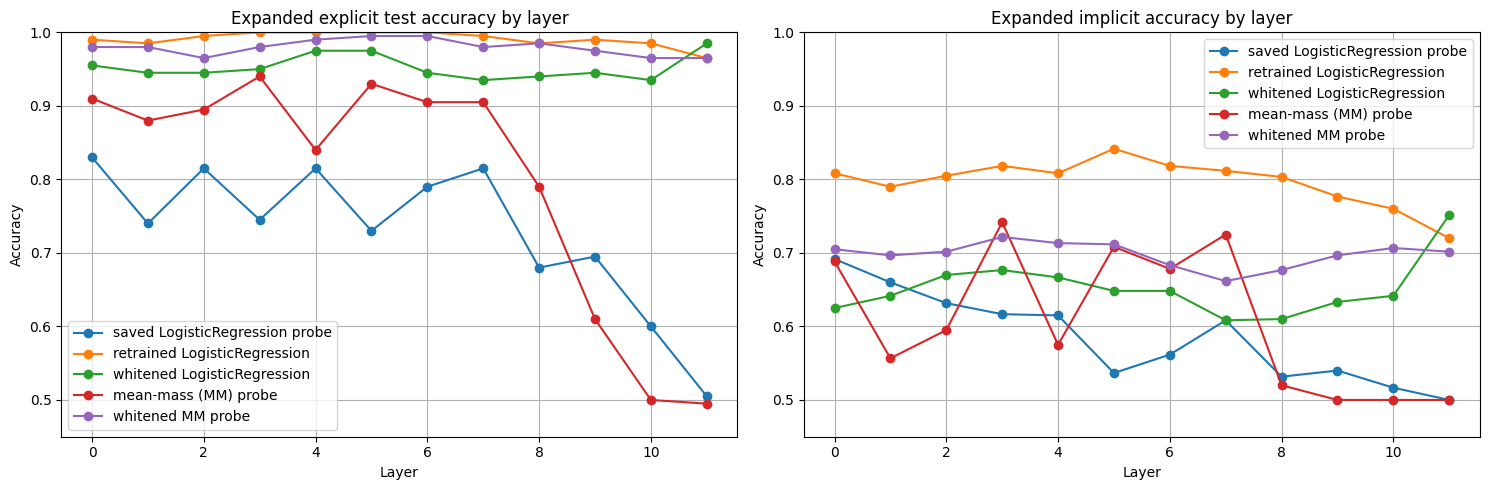

In [101]:
# Same final plot style as the main section
fig, ax = plt.subplots(1, 2, figsize=(15, 5.0))

# Explicit test split
ax[0].plot(saved_eval_df_expd.layer, saved_eval_df_expd.saved_probe_explicit_test_acc, marker='o', label='saved LogisticRegression probe')
ax[0].plot(retrain_df_expd.layer, retrain_df_expd.retrained_explicit_test_acc, marker='o', label='retrained LogisticRegression')
ax[0].plot(wlr_df_expd.layer, wlr_df_expd.wlr_explicit_test_acc, marker='o', label='whitened LogisticRegression')
ax[0].plot(mm_df_expd.layer, mm_df_expd.mm_explicit_test_acc, marker='o', label='mean-mass (MM) probe')
ax[0].plot(wmm_df_expd.layer, wmm_df_expd.wmm_explicit_test_acc, marker='o', label='whitened MM probe')
ax[0].set_title('Expanded explicit test accuracy by layer')
ax[0].set_xlabel('Layer')
ax[0].set_ylabel('Accuracy')
ax[0].set_ylim(0.45, 1.0)
ax[0].grid()
ax[0].legend()

# Implicit dataset
ax[1].plot(saved_eval_df_expd.layer, saved_eval_df_expd.saved_probe_implicit_acc, marker='o', label='saved LogisticRegression probe')
ax[1].plot(retrain_df_expd.layer, retrain_df_expd.retrained_implicit_acc, marker='o', label='retrained LogisticRegression')
ax[1].plot(wlr_df_expd.layer, wlr_df_expd.wlr_implicit_acc, marker='o', label='whitened LogisticRegression')
ax[1].plot(mm_df_expd.layer, mm_df_expd.mm_implicit_acc, marker='o', label='mean-mass (MM) probe')
ax[1].plot(wmm_df_expd.layer, wmm_df_expd.wmm_implicit_acc, marker='o', label='whitened MM probe')
ax[1].set_title('Expanded implicit accuracy by layer')
ax[1].set_xlabel('Layer')
ax[1].set_ylabel('Accuracy')
ax[1].set_ylim(0.45, 1.0)
ax[1].grid()
ax[1].legend()

plt.tight_layout()
plt.show()
#THIS PLOT - wmm and mm are suite 3


In [102]:
red_team_only_mm_checkpoint_rows = []
red_team_only_mm_expd_eval_rows = []

print('Red-team-only MM probe checkpoint dir:', red_team_only_mm_probe_dir)
print('Red-team-only training size:', len(y_redteam), '| class balance:', np.bincount(y_redteam))

for layer in range(n_layers):
    X_train = X_redteam[layer]
    y_train = y_redteam
    X_test = X_exp_expd[layer][test_idx_expd]
    y_test = y_exp_expd[test_idx_expd]

    mm_direction = train_mm_probe(X_train, y_train)
    mm_train_pred, mm_train_scores = mm_predict(X_train, mm_direction)
    mm_pred_test, _ = mm_predict(X_test, mm_direction)
    mm_pred_implicit, _ = mm_predict(X_imp_expd[layer], mm_direction)

    mm_score_scale = float(np.std(mm_train_scores))
    if (not np.isfinite(mm_score_scale)) or mm_score_scale <= 1e-8:
        mm_score_scale = float(np.mean(np.abs(mm_train_scores)))
    if (not np.isfinite(mm_score_scale)) or mm_score_scale <= 1e-8:
        mm_score_scale = 1.0

    checkpoint_payload = {
        'probe_type': 'mean_mass',
        'model_name': MODEL_NAME,
        'layer': int(layer),
        'train_dataset': 'red_team_only',
        'probe_format': PROBE_FORMAT_SLUG,
        'answer_pooling': 'mean_answer_token_activations',
        'option_labels_stripped': True,
        'red_team_run_id': RED_TEAM_RUN_ID,
        'red_team_example_count': int(len(y_redteam)),
        'train_size': int(len(y_train)),
        'test_size': int(len(test_idx_expd)),
        'train_accuracy': float((mm_train_pred == y_train).mean()),
        'test_accuracy': float((mm_pred_test == y_test).mean()),
        'implicit_accuracy': float((mm_pred_implicit == y_imp_expd).mean()),
        'direction_norm': float(np.linalg.norm(mm_direction)),
        'score_scale': mm_score_scale,
        'random_state': 42,
        'device': str(device),
        'created_at': pd.Timestamp.utcnow().strftime('%Y-%m-%dT%H:%M:%SZ'),
        'direction': mm_direction.astype(np.float32).tolist(),
    }

    checkpoint_path = red_team_only_mm_probe_dir / RED_TEAM_ONLY_MM_FILENAME_TEMPLATE.format(layer=layer)
    checkpoint_path.write_text(json.dumps(checkpoint_payload, indent=2) + '\\n', encoding='utf-8')

    red_team_only_mm_checkpoint_rows.append({
        'layer': layer,
        'checkpoint_path': str(checkpoint_path.relative_to(ROOT)),
        'train_size': int(len(y_train)),
        'train_accuracy': float((mm_train_pred == y_train).mean()),
        'direction_norm': float(np.linalg.norm(mm_direction)),
        'score_scale': mm_score_scale,
    })
    red_team_only_mm_expd_eval_rows.append({
        'layer': layer,
        'red_team_only_explicit_test_acc': float((mm_pred_test == y_test).mean()),
        'red_team_only_implicit_acc': float((mm_pred_implicit == y_imp_expd).mean()),
    })

red_team_only_mm_checkpoint_df = pd.DataFrame(red_team_only_mm_checkpoint_rows).sort_values('layer').reset_index(drop=True)
red_team_only_mm_expd_eval_df = pd.DataFrame(red_team_only_mm_expd_eval_rows).sort_values('layer').reset_index(drop=True)

print('Saved red-team-only GPT-2 MM probe checkpoints to', red_team_only_mm_probe_dir)
display(red_team_only_mm_checkpoint_df)
display(red_team_only_mm_expd_eval_df)


Red-team-only MM probe checkpoint dir: /Users/michalmraz/code/spar-ai/temporal-awareness/results/checkpoints/mmraz_probe_variations_red_team_only_20260322-090107_options_answer_stripped_mean_answer_tokens
Red-team-only training size: 190 | class balance: [98 92]
Saved red-team-only GPT-2 MM probe checkpoints to /Users/michalmraz/code/spar-ai/temporal-awareness/results/checkpoints/mmraz_probe_variations_red_team_only_20260322-090107_options_answer_stripped_mean_answer_tokens


/var/folders/t4/jszkcmcn7lvgmswvxnpyh1x00000gn/T/ipykernel_69730/4184612905.py:43: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  'created_at': pd.Timestamp.utcnow().strftime('%Y-%m-%dT%H:%M:%SZ'),


,layer,checkpoint_path,train_size,train_accuracy,direction_norm,score_scale
0,0,results/checkpoints/mmraz_probe_variations_red...,190,0.878947,4.225796,10.748392
1,1,results/checkpoints/mmraz_probe_variations_red...,190,0.900000,4.987788,14.914762
2,2,results/checkpoints/mmraz_probe_variations_red...,190,0.894737,6.003205,21.505857
3,3,results/checkpoints/mmraz_probe_variations_red...,190,0.684211,7.325065,31.752350
4,4,results/checkpoints/mmraz_probe_variations_red...,190,0.889474,8.358008,41.049065
5,5,results/checkpoints/mmraz_probe_variations_red...,190,0.884211,10.186553,61.984245
6,6,results/checkpoints/mmraz_probe_variations_red...,190,0.863158,12.947902,102.961578
7,7,results/checkpoints/mmraz_probe_variations_red...,190,0.868421,16.751503,172.261383
8,8,results/checkpoints/mmraz_probe_variations_red...,190,0.852632,19.758945,243.465073
9,9,results/checkpoints/mmraz_probe_variations_red...,190,0.678947,25.700596,418.683105


,layer,red_team_only_explicit_test_acc,red_team_only_implicit_acc
0,0,0.660,0.601667
1,1,0.560,0.538333
2,2,0.590,0.545000
3,3,0.840,0.738333
4,4,0.740,0.693333
5,5,0.795,0.736667
6,6,0.510,0.520000
7,7,0.755,0.693333
8,8,0.505,0.505000
9,9,0.500,0.500000


In [103]:
original_mm_rows_expd = []
original_mm_checkpoint_rows_expd = []

print('Original expanded-only MM probe checkpoint dir:', original_mm_probe_dir)

for layer in range(n_layers):
    X_train = X_exp_expd[layer][train_idx_expd]
    y_train = y_exp_expd[train_idx_expd]
    X_test = X_exp_expd[layer][test_idx_expd]
    y_test = y_exp_expd[test_idx_expd]

    mm_direction = train_mm_probe(X_train, y_train)
    mm_train_pred, mm_train_scores = mm_predict(X_train, mm_direction)
    mm_pred_test, _ = mm_predict(X_test, mm_direction)
    mm_pred_implicit, _ = mm_predict(X_imp_expd[layer], mm_direction)

    mm_score_scale = float(np.std(mm_train_scores))
    if (not np.isfinite(mm_score_scale)) or mm_score_scale <= 1e-8:
        mm_score_scale = float(np.mean(np.abs(mm_train_scores)))
    if (not np.isfinite(mm_score_scale)) or mm_score_scale <= 1e-8:
        mm_score_scale = 1.0

    checkpoint_payload = {
        'probe_type': 'mean_mass',
        'model_name': MODEL_NAME,
        'layer': int(layer),
        'train_dataset': 'expanded_explicit_only',
        'probe_format': PROBE_FORMAT_SLUG,
        'answer_pooling': 'mean_answer_token_activations',
        'option_labels_stripped': True,
        'explicit_dataset_path': str(explicit_expanded_path),
        'n_pairs': int(len(explicit_pairs_expd)),
        'n_samples': int(len(y_exp_expd)),
        'train_size': int(len(y_train)),
        'test_size': int(len(test_idx_expd)),
        'train_accuracy': float((mm_train_pred == y_train).mean()),
        'test_accuracy': float((mm_pred_test == y_test).mean()),
        'implicit_accuracy': float((mm_pred_implicit == y_imp_expd).mean()),
        'direction_norm': float(np.linalg.norm(mm_direction)),
        'score_scale': mm_score_scale,
        'random_state': 42,
        'device': str(device),
        'created_at': pd.Timestamp.utcnow().strftime('%Y-%m-%dT%H:%M:%SZ'),
        'direction': mm_direction.astype(np.float32).tolist(),
    }

    checkpoint_path = original_mm_probe_dir / ORIGINAL_MM_FILENAME_TEMPLATE.format(layer=layer)
    checkpoint_path.write_text(json.dumps(checkpoint_payload, indent=2) + '\\n', encoding='utf-8')

    original_mm_rows_expd.append({
        'layer': layer,
        'mm_explicit_test_acc': float((mm_pred_test == y_test).mean()),
        'mm_implicit_acc': float((mm_pred_implicit == y_imp_expd).mean()),
        'mm_direction_norm': float(np.linalg.norm(mm_direction)),
    })
    original_mm_checkpoint_rows_expd.append({
        'layer': layer,
        'checkpoint_path': str(checkpoint_path.relative_to(ROOT)),
        'test_accuracy': float((mm_pred_test == y_test).mean()),
        'implicit_accuracy': float((mm_pred_implicit == y_imp_expd).mean()),
        'score_scale': mm_score_scale,
    })

original_mm_df_expd = pd.DataFrame(original_mm_rows_expd).sort_values('layer').reset_index(drop=True)
original_mm_checkpoint_df_expd = pd.DataFrame(original_mm_checkpoint_rows_expd).sort_values('layer').reset_index(drop=True)

print('Saved original expanded-only GPT-2 MM probe checkpoints to', original_mm_probe_dir)
display(original_mm_checkpoint_df_expd)
display(original_mm_df_expd)


Original expanded-only MM probe checkpoint dir: /Users/michalmraz/code/spar-ai/temporal-awareness/results/checkpoints/mmraz_probe_variations_original_options_answer_stripped_mean_answer_tokens
Saved original expanded-only GPT-2 MM probe checkpoints to /Users/michalmraz/code/spar-ai/temporal-awareness/results/checkpoints/mmraz_probe_variations_original_options_answer_stripped_mean_answer_tokens


/var/folders/t4/jszkcmcn7lvgmswvxnpyh1x00000gn/T/ipykernel_69730/489676458.py:43: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  'created_at': pd.Timestamp.utcnow().strftime('%Y-%m-%dT%H:%M:%SZ'),


,layer,checkpoint_path,test_accuracy,implicit_accuracy,score_scale
0,0,results/checkpoints/mmraz_probe_variations_ori...,0.915,0.673333,25.679140
1,1,results/checkpoints/mmraz_probe_variations_ori...,0.865,0.523333,30.554199
2,2,results/checkpoints/mmraz_probe_variations_ori...,0.885,0.548333,38.967670
3,3,results/checkpoints/mmraz_probe_variations_ori...,0.945,0.695000,54.546791
4,4,results/checkpoints/mmraz_probe_variations_ori...,0.815,0.548333,64.720322
5,5,results/checkpoints/mmraz_probe_variations_ori...,0.900,0.636667,87.749504
6,6,results/checkpoints/mmraz_probe_variations_ori...,0.920,0.666667,108.684868
7,7,results/checkpoints/mmraz_probe_variations_ori...,0.900,0.653333,148.674591
8,8,results/checkpoints/mmraz_probe_variations_ori...,0.815,0.520000,186.151718
9,9,results/checkpoints/mmraz_probe_variations_ori...,0.785,0.515000,247.516800


,layer,mm_explicit_test_acc,mm_implicit_acc,mm_direction_norm
0,0,0.915,0.673333,6.499283
1,1,0.865,0.523333,7.131767
2,2,0.885,0.548333,8.047041
3,3,0.945,0.695000,9.538021
4,4,0.815,0.548333,10.398585
5,5,0.900,0.636667,12.035578
6,6,0.920,0.666667,13.368293
7,7,0.900,0.653333,15.618121
8,8,0.815,0.520000,17.312454
9,9,0.785,0.515000,19.739948


# Red teaming value-add

,layer,original_explicit_test_acc,original_implicit_acc,red_team_augmented_explicit_test_acc,red_team_augmented_implicit_acc,red_team_only_explicit_test_acc,red_team_only_implicit_acc
0,0,0.915,0.673333,0.910,0.688333,0.660,0.601667
1,1,0.865,0.523333,0.880,0.556667,0.560,0.538333
2,2,0.885,0.548333,0.895,0.595000,0.590,0.545000
3,3,0.945,0.695000,0.940,0.741667,0.840,0.738333
4,4,0.815,0.548333,0.840,0.575000,0.740,0.693333
5,5,0.900,0.636667,0.930,0.708333,0.795,0.736667
6,6,0.920,0.666667,0.905,0.678333,0.510,0.520000
7,7,0.900,0.653333,0.905,0.725000,0.755,0.693333
8,8,0.815,0.520000,0.790,0.520000,0.505,0.505000
9,9,0.785,0.515000,0.610,0.500000,0.500,0.500000


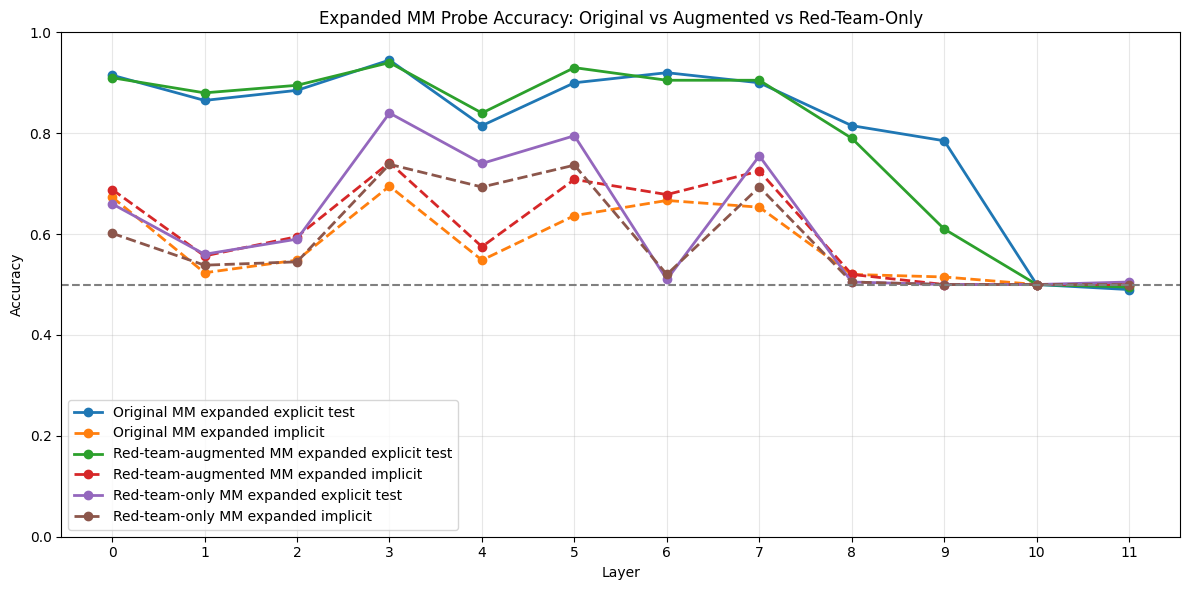

In [104]:
mm_accuracy_comparison_df = (
    original_mm_df_expd[['layer', 'mm_explicit_test_acc', 'mm_implicit_acc']]
    .rename(
        columns={
            'mm_explicit_test_acc': 'original_explicit_test_acc',
            'mm_implicit_acc': 'original_implicit_acc',
        }
    )
    .merge(
        mm_df_expd[['layer', 'mm_explicit_test_acc', 'mm_implicit_acc']].rename(
            columns={
                'mm_explicit_test_acc': 'red_team_augmented_explicit_test_acc',
                'mm_implicit_acc': 'red_team_augmented_implicit_acc',
            }
        ),
        on='layer',
        how='inner',
    )
    .merge(
        red_team_only_mm_expd_eval_df,
        on='layer',
        how='inner',
    )
    .sort_values('layer')
    .reset_index(drop=True)
)

display(mm_accuracy_comparison_df)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(
    mm_accuracy_comparison_df['layer'],
    mm_accuracy_comparison_df['original_explicit_test_acc'],
    marker='o',
    linewidth=2,
    label='Original MM expanded explicit test',
)
ax.plot(
    mm_accuracy_comparison_df['layer'],
    mm_accuracy_comparison_df['original_implicit_acc'],
    marker='o',
    linewidth=2,
    linestyle='--',
    label='Original MM expanded implicit',
)
ax.plot(
    mm_accuracy_comparison_df['layer'],
    mm_accuracy_comparison_df['red_team_augmented_explicit_test_acc'],
    marker='o',
    linewidth=2,
    label='Red-team-augmented MM expanded explicit test',
)
ax.plot(
    mm_accuracy_comparison_df['layer'],
    mm_accuracy_comparison_df['red_team_augmented_implicit_acc'],
    marker='o',
    linewidth=2,
    linestyle='--',
    label='Red-team-augmented MM expanded implicit',
)
ax.plot(
    mm_accuracy_comparison_df['layer'],
    mm_accuracy_comparison_df['red_team_only_explicit_test_acc'],
    marker='o',
    linewidth=2,
    label='Red-team-only MM expanded explicit test',
)
ax.plot(
    mm_accuracy_comparison_df['layer'],
    mm_accuracy_comparison_df['red_team_only_implicit_acc'],
    marker='o',
    linewidth=2,
    linestyle='--',
    label='Red-team-only MM expanded implicit',
)

ax.set_title('Expanded MM Probe Accuracy: Original vs Augmented vs Red-Team-Only')
ax.set_xlabel('Layer')
ax.set_ylabel('Accuracy')
ax.set_xticks(mm_accuracy_comparison_df['layer'])
ax.set_ylim(0.0, 1.0)
ax.axhline(0.5, color='gray', linestyle='--')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


,layer,original_mm_red_team_acc,red_team_augmented_mm_red_team_acc,red_team_only_mm_red_team_acc
0,0,0.868421,0.931579,0.878947
1,1,0.763158,0.826316,0.900000
2,2,0.773684,0.831579,0.894737
3,3,0.715789,0.905263,0.684211
4,4,0.531579,0.652632,0.889474
5,5,0.673684,0.884211,0.884211
6,6,0.900000,0.926316,0.863158
7,7,0.847368,0.873684,0.868421
8,8,0.863158,0.878947,0.852632
9,9,0.878947,0.794737,0.678947


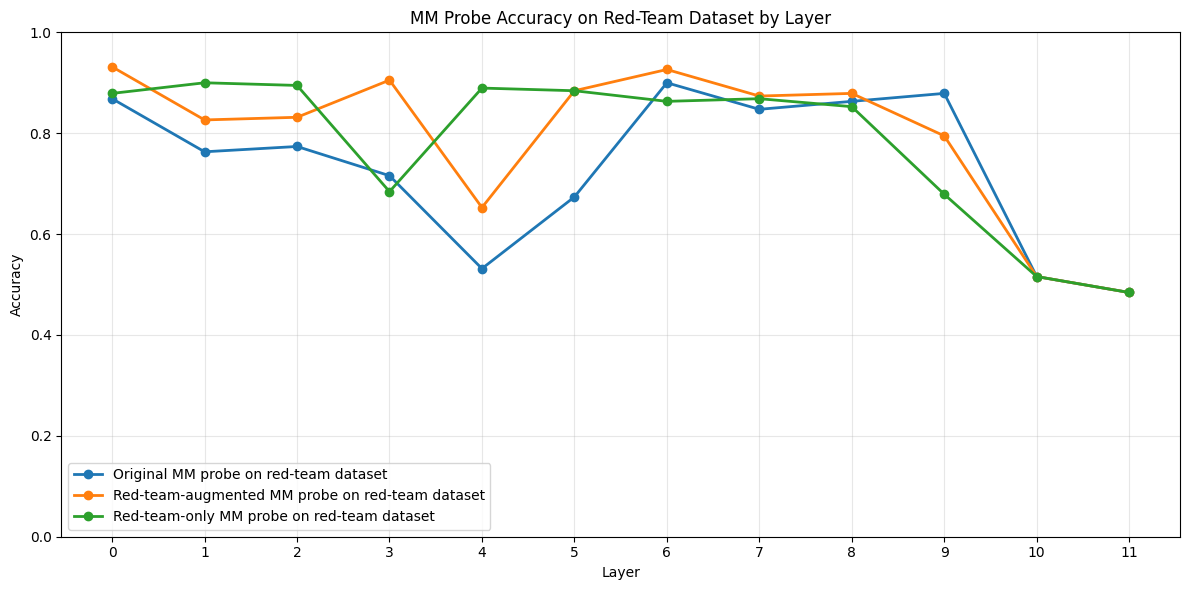

In [105]:
def load_mm_checkpoint_payload(checkpoint_path):
    text = Path(checkpoint_path).read_text()
    try:
        return json.loads(text)
    except json.JSONDecodeError as exc:
        try:
            payload, end = json.JSONDecoder().raw_decode(text)
        except json.JSONDecodeError:
            raise exc
        trailing = text[end:]
        normalized_trailing = trailing.replace('\\n', '').replace('\\r', '').strip()
        if normalized_trailing:
            raise exc
        return payload


def score_mm_checkpoint_on_dataset(checkpoint_path, activations_by_layer, labels, layer):
    payload = load_mm_checkpoint_payload(checkpoint_path)
    direction = np.asarray(payload['direction'], dtype=np.float32)
    scores = activations_by_layer[layer] @ direction
    predictions = (scores > 0).astype(np.int64)
    return float((predictions == labels).mean())


red_team_mm_eval_rows = []

for layer in range(n_layers):
    original_checkpoint_path = original_mm_probe_dir / ORIGINAL_MM_FILENAME_TEMPLATE.format(layer=layer)
    augmented_checkpoint_path = red_team_augmented_probe_dir / AUGMENTED_MM_FILENAME_TEMPLATE.format(layer=layer)
    red_team_only_checkpoint_path = red_team_only_mm_probe_dir / RED_TEAM_ONLY_MM_FILENAME_TEMPLATE.format(layer=layer)

    if not original_checkpoint_path.exists():
        raise FileNotFoundError('Missing original MM checkpoint: ' + str(original_checkpoint_path))
    if not augmented_checkpoint_path.exists():
        raise FileNotFoundError('Missing red-team-augmented MM checkpoint: ' + str(augmented_checkpoint_path))
    if not red_team_only_checkpoint_path.exists():
        raise FileNotFoundError('Missing red-team-only MM checkpoint: ' + str(red_team_only_checkpoint_path))

    red_team_mm_eval_rows.append({
        'layer': layer,
        'original_mm_red_team_acc': score_mm_checkpoint_on_dataset(
            original_checkpoint_path,
            X_redteam,
            y_redteam,
            layer,
        ),
        'red_team_augmented_mm_red_team_acc': score_mm_checkpoint_on_dataset(
            augmented_checkpoint_path,
            X_redteam,
            y_redteam,
            layer,
        ),
        'red_team_only_mm_red_team_acc': score_mm_checkpoint_on_dataset(
            red_team_only_checkpoint_path,
            X_redteam,
            y_redteam,
            layer,
        ),
    })

red_team_mm_eval_df = pd.DataFrame(red_team_mm_eval_rows).sort_values('layer').reset_index(drop=True)
display(red_team_mm_eval_df)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(
    red_team_mm_eval_df['layer'],
    red_team_mm_eval_df['original_mm_red_team_acc'],
    marker='o',
    linewidth=2,
    label='Original MM probe on red-team dataset',
)
ax.plot(
    red_team_mm_eval_df['layer'],
    red_team_mm_eval_df['red_team_augmented_mm_red_team_acc'],
    marker='o',
    linewidth=2,
    label='Red-team-augmented MM probe on red-team dataset',
)
ax.plot(
    red_team_mm_eval_df['layer'],
    red_team_mm_eval_df['red_team_only_mm_red_team_acc'],
    marker='o',
    linewidth=2,
    label='Red-team-only MM probe on red-team dataset',
)

ax.set_title('MM Probe Accuracy on Red-Team Dataset by Layer')
ax.set_xlabel('Layer')
ax.set_ylabel('Accuracy')
ax.set_xticks(red_team_mm_eval_df['layer'])
ax.set_ylim(0.0, 1.0)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


In [106]:
def load_mm_checkpoint_payload(checkpoint_path):
    text = Path(checkpoint_path).read_text()
    try:
        return json.loads(text)
    except json.JSONDecodeError as exc:
        try:
            payload, end = json.JSONDecoder().raw_decode(text)
        except json.JSONDecodeError:
            raise exc
        trailing = text[end:]
        normalized_trailing = trailing.replace('\\n', '').replace('\\r', '').strip()
        if normalized_trailing:
            raise exc
        return payload


def load_mm_direction(checkpoint_path):
    payload = load_mm_checkpoint_payload(checkpoint_path)
    return np.asarray(payload['direction'], dtype=np.float32)


def cosine_between(a, b):
    return float(np.dot(a, b) / ((np.linalg.norm(a) * np.linalg.norm(b)) + 1e-12))


mm_probe_cosine_rows = []

for layer in range(n_layers):
    original_checkpoint_path = original_mm_probe_dir / ORIGINAL_MM_FILENAME_TEMPLATE.format(layer=layer)
    augmented_checkpoint_path = red_team_augmented_probe_dir / AUGMENTED_MM_FILENAME_TEMPLATE.format(layer=layer)
    red_team_only_checkpoint_path = red_team_only_mm_probe_dir / RED_TEAM_ONLY_MM_FILENAME_TEMPLATE.format(layer=layer)

    if not original_checkpoint_path.exists():
        raise FileNotFoundError('Missing original MM checkpoint: ' + str(original_checkpoint_path))
    if not augmented_checkpoint_path.exists():
        raise FileNotFoundError('Missing red-team-augmented MM checkpoint: ' + str(augmented_checkpoint_path))
    if not red_team_only_checkpoint_path.exists():
        raise FileNotFoundError('Missing red-team-only MM checkpoint: ' + str(red_team_only_checkpoint_path))

    original_direction = load_mm_direction(original_checkpoint_path)
    augmented_direction = load_mm_direction(augmented_checkpoint_path)
    red_team_only_direction = load_mm_direction(red_team_only_checkpoint_path)

    mm_probe_cosine_rows.append({
        'layer': layer,
        'original_direction_norm': float(np.linalg.norm(original_direction)),
        'red_team_augmented_direction_norm': float(np.linalg.norm(augmented_direction)),
        'red_team_only_direction_norm': float(np.linalg.norm(red_team_only_direction)),
        'original_vs_red_team_augmented_cosine': cosine_between(original_direction, augmented_direction),
        'original_vs_red_team_only_cosine': cosine_between(original_direction, red_team_only_direction),
        'red_team_augmented_vs_red_team_only_cosine': cosine_between(augmented_direction, red_team_only_direction),
    })

mm_probe_cosine_df = pd.DataFrame(mm_probe_cosine_rows).sort_values('layer').reset_index(drop=True)
display(mm_probe_cosine_df)
layer6 = mm_probe_cosine_df.loc[mm_probe_cosine_df.layer == 6].iloc[0]
print('Layer 6 original vs red-team-augmented cosine:', round(float(layer6['original_vs_red_team_augmented_cosine']), 6))
print('Layer 6 original vs red-team-only cosine:', round(float(layer6['original_vs_red_team_only_cosine']), 6))
print('Layer 6 red-team-augmented vs red-team-only cosine:', round(float(layer6['red_team_augmented_vs_red_team_only_cosine']), 6))


,layer,original_direction_norm,red_team_augmented_direction_norm,red_team_only_direction_norm,original_vs_red_team_augmented_cosine,original_vs_red_team_only_cosine,red_team_augmented_vs_red_team_only_cosine
0,0,6.499283,5.684402,4.225796,0.992562,0.473853,0.575014
1,1,7.131767,6.267782,4.987788,0.991384,0.464151,0.573908
2,2,8.047041,7.056375,6.003205,0.989470,0.415453,0.540632
3,3,9.538021,8.363085,7.325065,0.988481,0.401861,0.533819
4,4,10.398585,9.094409,8.358008,0.986735,0.366434,0.510680
5,5,12.035578,10.525959,10.186553,0.984652,0.338114,0.495092
6,6,13.368293,11.829086,12.947902,0.980743,0.333690,0.509326
7,7,15.618121,14.032363,16.751503,0.977069,0.353331,0.542770
8,8,17.312454,15.648711,19.758945,0.974879,0.350943,0.548818
9,9,19.739948,18.085518,25.700596,0.968144,0.331954,0.556042


Layer 6 original vs red-team-augmented cosine: 0.980743
Layer 6 original vs red-team-only cosine: 0.33369
Layer 6 red-team-augmented vs red-team-only cosine: 0.509326


In [107]:
kek

NameError: name 'kek' is not defined

In [ ]:
# Serialize all fitted probe families so they can be reused outside the notebook.
BASE_RED_TEAM_AUGMENTED_PROBE_DIR = ROOT / 'results/checkpoints' / (
    'mmraz_probe_variations_base_red_team_augmented_' + RED_TEAM_RUN_ID + '_' + PROBE_FORMAT_SLUG
)
BASE_RED_TEAM_AUGMENTED_PREFIX = 'mmraz_gpt2_base_explicit_plus_redteam_options_answer'
EXPANDED_RED_TEAM_AUGMENTED_PREFIX = 'mmraz_gpt2_explicit_expanded_plus_redteam_options_answer'
EXPANDED_ORIGINAL_PREFIX = 'mmraz_gpt2_explicit_expanded_options_answer'
RED_TEAM_ONLY_PREFIX = 'mmraz_gpt2_redteam_only_options_answer'

for checkpoint_dir in [
    BASE_RED_TEAM_AUGMENTED_PROBE_DIR,
    red_team_augmented_probe_dir,
    original_mm_probe_dir,
    red_team_only_mm_probe_dir,
]:
    checkpoint_dir.mkdir(parents=True, exist_ok=True)


def relative_to_root(path):
    path = Path(path)
    try:
        return str(path.relative_to(ROOT))
    except ValueError:
        return str(path)



def write_json(path, payload):
    Path(path).write_text(json.dumps(payload, indent=2) + '\n', encoding='utf-8')



def compute_score_scale(scores):
    score_scale = float(np.std(scores))
    if (not np.isfinite(score_scale)) or score_scale <= 1e-8:
        score_scale = float(np.mean(np.abs(scores)))
    if (not np.isfinite(score_scale)) or score_scale <= 1e-8:
        score_scale = 1.0
    return score_scale



def save_whitener_artifact(dir_path, prefix, layer, whitener, metadata):
    arrays_path = dir_path / f'{prefix}_whitener_layer_{layer}.npz'
    np.savez_compressed(
        arrays_path,
        mean_train=np.asarray(whitener['mean_train'], dtype=np.float32),
        inv_sqrt=np.asarray(whitener['inv_sqrt'], dtype=np.float32),
    )

    metadata_path = dir_path / f'{prefix}_whitener_layer_{layer}.json'
    metadata_payload = {
        **metadata,
        'artifact_type': 'whitener',
        'transform_type': 'center_then_right_multiply_inv_sqrt',
        'mean_shape': list(np.asarray(whitener['mean_train']).shape),
        'inv_sqrt_shape': list(np.asarray(whitener['inv_sqrt']).shape),
        'reg': float(whitener['reg']),
        'cov_reg_condition_number': float(whitener['cov_reg_condition_number']),
        'array_path': relative_to_root(arrays_path),
    }
    write_json(metadata_path, metadata_payload)
    return metadata_path, arrays_path



def save_probe_suite(
    dir_path,
    prefix,
    train_dataset,
    train_layers,
    y_train,
    test_layers,
    y_test,
    implicit_layers,
    y_implicit,
    dataset_metadata,
    mm_filename_template=None,
):
    dir_path = Path(dir_path)
    dir_path.mkdir(parents=True, exist_ok=True)

    metrics_rows = []
    artifact_rows = []

    for layer in range(n_layers):
        X_train = np.asarray(train_layers[layer], dtype=np.float32)
        X_test = np.asarray(test_layers[layer], dtype=np.float32)
        X_implicit = np.asarray(implicit_layers[layer], dtype=np.float32)
        X_redteam_layer = np.asarray(X_redteam[layer], dtype=np.float32)

        common_metadata = {
            'model_name': MODEL_NAME,
            'layer': int(layer),
            'train_dataset': train_dataset,
            'probe_format': PROBE_FORMAT_SLUG,
            'answer_pooling': 'mean_answer_token_activations',
            'option_labels_stripped': True,
            'train_size': int(len(y_train)),
            'test_size': int(len(y_test)),
            'implicit_size': int(len(y_implicit)),
            'red_team_size': int(len(y_redteam)),
            'random_state': 42,
            'device': str(device),
            **dataset_metadata,
        }

        clf = LogisticRegression(max_iter=1000, random_state=42)
        clf.fit(X_train, y_train)
        lr_train_acc = float(clf.score(X_train, y_train))
        lr_test_acc = float(clf.score(X_test, y_test))
        lr_implicit_acc = float(clf.score(X_implicit, y_implicit))
        lr_red_team_acc = float(clf.score(X_redteam_layer, y_redteam))
        lr_path = dir_path / f'{prefix}_lr_probe_layer_{layer}.json'
        write_json(lr_path, {
            **common_metadata,
            'artifact_type': 'probe',
            'probe_type': 'logistic_regression',
            'feature_space': 'raw',
            'train_accuracy': lr_train_acc,
            'test_accuracy': lr_test_acc,
            'implicit_accuracy': lr_implicit_acc,
            'red_team_accuracy': lr_red_team_acc,
            'coef': clf.coef_.astype(np.float32).ravel().tolist(),
            'intercept': float(clf.intercept_[0]),
            'classes': [int(v) for v in clf.classes_.tolist()],
            'n_iter': int(np.asarray(clf.n_iter_).ravel()[0]),
        })
        artifact_rows.append({
            'layer': int(layer),
            'artifact_type': 'probe',
            'probe_type': 'logistic_regression',
            'feature_space': 'raw',
            'json_path': relative_to_root(lr_path),
            'array_path': '',
        })

        whitener = fit_whitener(X_train, reg=whiten_reg)
        whitener_metadata_path, whitener_arrays_path = save_whitener_artifact(
            dir_path,
            prefix,
            layer,
            whitener,
            common_metadata,
        )
        artifact_rows.append({
            'layer': int(layer),
            'artifact_type': 'whitener',
            'probe_type': 'shared_whitener',
            'feature_space': 'raw_to_whitened',
            'json_path': relative_to_root(whitener_metadata_path),
            'array_path': relative_to_root(whitener_arrays_path),
        })

        X_train_w = apply_whitener(X_train, whitener)
        X_test_w = apply_whitener(X_test, whitener)
        X_implicit_w = apply_whitener(X_implicit, whitener)
        X_redteam_w = apply_whitener(X_redteam_layer, whitener)

        clf_w = LogisticRegression(max_iter=1000, random_state=42)
        clf_w.fit(X_train_w, y_train)
        wlr_train_acc = float(clf_w.score(X_train_w, y_train))
        wlr_test_acc = float(clf_w.score(X_test_w, y_test))
        wlr_implicit_acc = float(clf_w.score(X_implicit_w, y_implicit))
        wlr_red_team_acc = float(clf_w.score(X_redteam_w, y_redteam))
        wlr_path = dir_path / f'{prefix}_wlr_probe_layer_{layer}.json'
        write_json(wlr_path, {
            **common_metadata,
            'artifact_type': 'probe',
            'probe_type': 'logistic_regression',
            'feature_space': 'whitened',
            'train_accuracy': wlr_train_acc,
            'test_accuracy': wlr_test_acc,
            'implicit_accuracy': wlr_implicit_acc,
            'red_team_accuracy': wlr_red_team_acc,
            'coef': clf_w.coef_.astype(np.float32).ravel().tolist(),
            'intercept': float(clf_w.intercept_[0]),
            'classes': [int(v) for v in clf_w.classes_.tolist()],
            'n_iter': int(np.asarray(clf_w.n_iter_).ravel()[0]),
            'whitener_metadata_path': relative_to_root(whitener_metadata_path),
            'whitener_array_path': relative_to_root(whitener_arrays_path),
        })
        artifact_rows.append({
            'layer': int(layer),
            'artifact_type': 'probe',
            'probe_type': 'logistic_regression',
            'feature_space': 'whitened',
            'json_path': relative_to_root(wlr_path),
            'array_path': '',
        })

        mm_direction = train_mm_probe(X_train, y_train).astype(np.float32)
        mm_train_pred, mm_train_scores = mm_predict(X_train, mm_direction)
        mm_pred_test, _ = mm_predict(X_test, mm_direction)
        mm_pred_implicit, _ = mm_predict(X_implicit, mm_direction)
        mm_pred_redteam, _ = mm_predict(X_redteam_layer, mm_direction)
        mm_score_scale = compute_score_scale(mm_train_scores)
        if mm_filename_template is None:
            mm_path = dir_path / f'{prefix}_mm_probe_layer_{layer}.json'
        else:
            mm_path = dir_path / mm_filename_template.format(layer=layer)
        write_json(mm_path, {
            **common_metadata,
            'artifact_type': 'probe',
            'probe_type': 'mean_mass',
            'feature_space': 'raw',
            'train_accuracy': float((mm_train_pred == y_train).mean()),
            'test_accuracy': float((mm_pred_test == y_test).mean()),
            'implicit_accuracy': float((mm_pred_implicit == y_implicit).mean()),
            'red_team_accuracy': float((mm_pred_redteam == y_redteam).mean()),
            'direction_norm': float(np.linalg.norm(mm_direction)),
            'score_scale': mm_score_scale,
            'direction': mm_direction.tolist(),
        })
        artifact_rows.append({
            'layer': int(layer),
            'artifact_type': 'probe',
            'probe_type': 'mean_mass',
            'feature_space': 'raw',
            'json_path': relative_to_root(mm_path),
            'array_path': '',
        })

        whitened_mm_direction = (np.asarray(whitener['inv_sqrt']) @ mm_direction).astype(np.float32)
        wmm_train_scores = X_train_w @ whitened_mm_direction
        wmm_test_scores = X_test_w @ whitened_mm_direction
        wmm_implicit_scores = X_implicit_w @ whitened_mm_direction
        wmm_redteam_scores = X_redteam_w @ whitened_mm_direction
        wmm_path = dir_path / f'{prefix}_wmm_probe_layer_{layer}.json'
        write_json(wmm_path, {
            **common_metadata,
            'artifact_type': 'probe',
            'probe_type': 'mean_mass',
            'feature_space': 'whitened',
            'score_rule': 'score = ((x - mean_train) @ inv_sqrt) dot probe_direction',
            'train_accuracy': float(((wmm_train_scores > 0).astype(np.int64) == y_train).mean()),
            'test_accuracy': float(((wmm_test_scores > 0).astype(np.int64) == y_test).mean()),
            'implicit_accuracy': float(((wmm_implicit_scores > 0).astype(np.int64) == y_implicit).mean()),
            'red_team_accuracy': float(((wmm_redteam_scores > 0).astype(np.int64) == y_redteam).mean()),
            'probe_direction_norm': float(np.linalg.norm(whitened_mm_direction)),
            'score_scale': compute_score_scale(wmm_train_scores),
            'probe_direction': whitened_mm_direction.tolist(),
            'raw_mm_direction': mm_direction.tolist(),
            'whitener_metadata_path': relative_to_root(whitener_metadata_path),
            'whitener_array_path': relative_to_root(whitener_arrays_path),
        })
        artifact_rows.append({
            'layer': int(layer),
            'artifact_type': 'probe',
            'probe_type': 'mean_mass',
            'feature_space': 'whitened',
            'json_path': relative_to_root(wmm_path),
            'array_path': '',
        })

        metrics_rows.append({
            'layer': int(layer),
            'train_dataset': train_dataset,
            'lr_train_acc': lr_train_acc,
            'lr_explicit_test_acc': lr_test_acc,
            'lr_implicit_acc': lr_implicit_acc,
            'lr_red_team_acc': lr_red_team_acc,
            'wlr_train_acc': wlr_train_acc,
            'wlr_explicit_test_acc': wlr_test_acc,
            'wlr_implicit_acc': wlr_implicit_acc,
            'wlr_red_team_acc': wlr_red_team_acc,
            'mm_train_acc': float((mm_train_pred == y_train).mean()),
            'mm_explicit_test_acc': float((mm_pred_test == y_test).mean()),
            'mm_implicit_acc': float((mm_pred_implicit == y_implicit).mean()),
            'mm_red_team_acc': float((mm_pred_redteam == y_redteam).mean()),
            'mm_direction_norm': float(np.linalg.norm(mm_direction)),
            'wmm_train_acc': float(((wmm_train_scores > 0).astype(np.int64) == y_train).mean()),
            'wmm_explicit_test_acc': float(((wmm_test_scores > 0).astype(np.int64) == y_test).mean()),
            'wmm_implicit_acc': float(((wmm_implicit_scores > 0).astype(np.int64) == y_implicit).mean()),
            'wmm_red_team_acc': float(((wmm_redteam_scores > 0).astype(np.int64) == y_redteam).mean()),
            'wmm_probe_direction_norm': float(np.linalg.norm(whitened_mm_direction)),
            'whitener_reg': float(whitener['reg']),
            'whitener_cov_reg_condition_number': float(whitener['cov_reg_condition_number']),
        })

    metrics_df = pd.DataFrame(metrics_rows).sort_values('layer').reset_index(drop=True)
    artifact_df = pd.DataFrame(artifact_rows).sort_values(['layer', 'artifact_type', 'probe_type', 'feature_space']).reset_index(drop=True)
    metrics_path = dir_path / f'{prefix}_metrics_by_layer.csv'
    artifact_index_path = dir_path / f'{prefix}_artifact_index.csv'
    metrics_df.to_csv(metrics_path, index=False)
    artifact_df.to_csv(artifact_index_path, index=False)
    metrics_df.attrs['metrics_path'] = str(metrics_path)
    artifact_df.attrs['artifact_index_path'] = str(artifact_index_path)
    print('Saved probe suite:', dir_path)
    print('  metrics:', metrics_path)
    print('  artifact index:', artifact_index_path)
    return metrics_df, artifact_df


X_base_augmented_train = [
    np.concatenate([X_exp[layer][train_idx], X_redteam[layer]], axis=0)
    for layer in range(n_layers)
]
y_base_augmented = np.concatenate([y_exp[train_idx], y_redteam], axis=0)

X_expanded_augmented_train = [
    np.concatenate([X_exp_expd[layer][train_idx_expd], X_redteam[layer]], axis=0)
    for layer in range(n_layers)
]
y_expanded_augmented = np.concatenate([y_exp_expd[train_idx_expd], y_redteam], axis=0)

X_expanded_original_train = [
    X_exp_expd[layer][train_idx_expd]
    for layer in range(n_layers)
]
y_expanded_original = y_exp_expd[train_idx_expd]

suite_results = {}
suite_results['base_explicit_plus_redteam'] = save_probe_suite(
    dir_path=BASE_RED_TEAM_AUGMENTED_PROBE_DIR,
    prefix=BASE_RED_TEAM_AUGMENTED_PREFIX,
    train_dataset='base_explicit_plus_redteam',
    train_layers=X_base_augmented_train,
    y_train=y_base_augmented,
    test_layers=[X_exp[layer][test_idx] for layer in range(n_layers)],
    y_test=y_exp[test_idx],
    implicit_layers=X_imp,
    y_implicit=y_imp,
    dataset_metadata={
        'explicit_dataset_path': str(explicit_path),
        'implicit_dataset_path': str(implicit_path),
        'adversarial_run_id': RED_TEAM_RUN_ID,
        'adversarial_example_count': int(len(y_redteam)),
        'train_size_base': int(len(train_idx)),
    },
)
suite_results['expanded_explicit_plus_redteam'] = save_probe_suite(
    dir_path=red_team_augmented_probe_dir,
    prefix=EXPANDED_RED_TEAM_AUGMENTED_PREFIX,
    train_dataset='expanded_explicit_plus_redteam',
    train_layers=X_expanded_augmented_train,
    y_train=y_expanded_augmented,
    test_layers=[X_exp_expd[layer][test_idx_expd] for layer in range(n_layers)],
    y_test=y_exp_expd[test_idx_expd],
    implicit_layers=X_imp_expd,
    y_implicit=y_imp_expd,
    dataset_metadata={
        'explicit_dataset_path': str(explicit_expanded_path),
        'implicit_dataset_path': str(implicit_expanded_path),
        'adversarial_run_id': RED_TEAM_RUN_ID,
        'adversarial_example_count': int(len(y_redteam)),
        'train_size_base': int(len(train_idx_expd)),
        'n_pairs': int(len(explicit_pairs_expd)),
    },
    mm_filename_template=AUGMENTED_MM_FILENAME_TEMPLATE,
)
suite_results['expanded_explicit_only'] = save_probe_suite(
    dir_path=original_mm_probe_dir,
    prefix=EXPANDED_ORIGINAL_PREFIX,
    train_dataset='expanded_explicit_only',
    train_layers=X_expanded_original_train,
    y_train=y_expanded_original,
    test_layers=[X_exp_expd[layer][test_idx_expd] for layer in range(n_layers)],
    y_test=y_exp_expd[test_idx_expd],
    implicit_layers=X_imp_expd,
    y_implicit=y_imp_expd,
    dataset_metadata={
        'explicit_dataset_path': str(explicit_expanded_path),
        'implicit_dataset_path': str(implicit_expanded_path),
        'n_pairs': int(len(explicit_pairs_expd)),
    },
    mm_filename_template=ORIGINAL_MM_FILENAME_TEMPLATE,
)
suite_results['red_team_only'] = save_probe_suite(
    dir_path=red_team_only_mm_probe_dir,
    prefix=RED_TEAM_ONLY_PREFIX,
    train_dataset='red_team_only',
    train_layers=X_redteam,
    y_train=y_redteam,
    test_layers=[X_exp_expd[layer][test_idx_expd] for layer in range(n_layers)],
    y_test=y_exp_expd[test_idx_expd],
    implicit_layers=X_imp_expd,
    y_implicit=y_imp_expd,
    dataset_metadata={
        'red_team_run_id': RED_TEAM_RUN_ID,
        'red_team_example_count': int(len(y_redteam)),
        'explicit_dataset_path': str(explicit_expanded_path),
        'implicit_dataset_path': str(implicit_expanded_path),
    },
    mm_filename_template=RED_TEAM_ONLY_MM_FILENAME_TEMPLATE,
)

storage_overview_df = pd.DataFrame([
    {
        'suite': key,
        'metrics_path': relative_to_root(result[0].attrs['metrics_path']),
        'artifact_index_path': relative_to_root(result[1].attrs['artifact_index_path']),
        'artifact_count': int(len(result[1])),
    }
    for key, result in suite_results.items()
])

display(storage_overview_df)
display({key: value[0].head() for key, value in suite_results.items()})


/Users/michalmraz/opt/anaconda3/envs/temporal-awareness-venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Saved probe suite: /Users/michalmraz/code/spar-ai/temporal-awareness/results/checkpoints/mmraz_probe_variations_base_red_team_augmented_20260322-090107_options_answer_stripped_mean_answer_tokens
  metrics: /Users/michalmraz/code/spar-ai/temporal-awareness/results/checkpoints/mmraz_probe_variations_base_red_team_augmented_20260322-090107_options_answer_stripped_mean_answer_tokens/mmraz_gpt2_base_explicit_plus_redteam_options_answer_metrics_by_layer.csv
  artifact index: /Users/michalmraz/code/spar-ai/temporal-awareness/results/checkpoints/mmraz_probe_variations_base_red_team_augmented_20260322-090107_options_answer_stripped_mean_answer_tokens/mmraz_gpt2_base_explicit_plus_redteam_options_answer_artifact_index.csv
Saved probe suite: /Users/michalmraz/code/spar-ai/temporal-awareness/results/checkpoints/mmraz_probe_variations_red_team_augmented_20260322-090107_options_answer_stripped_mean_answer_tokens
  metrics: /Users/michalmraz/code/spar-ai/temporal-awareness/results/checkpoints/mmraz_p

,suite,metrics_path,artifact_index_path,artifact_count
0,base_explicit_plus_redteam,results/checkpoints/mmraz_probe_variations_bas...,results/checkpoints/mmraz_probe_variations_bas...,60
1,expanded_explicit_plus_redteam,results/checkpoints/mmraz_probe_variations_red...,results/checkpoints/mmraz_probe_variations_red...,60
2,expanded_explicit_only,results/checkpoints/mmraz_probe_variations_ori...,results/checkpoints/mmraz_probe_variations_ori...,60
3,red_team_only,results/checkpoints/mmraz_probe_variations_red...,results/checkpoints/mmraz_probe_variations_red...,60


{'base_explicit_plus_redteam':    layer               train_dataset  lr_train_acc  lr_explicit_test_acc  \
 0      0  base_explicit_plus_redteam           1.0                  0.80   
 1      1  base_explicit_plus_redteam           1.0                  0.90   
 2      2  base_explicit_plus_redteam           1.0                  0.90   
 3      3  base_explicit_plus_redteam           1.0                  0.85   
 4      4  base_explicit_plus_redteam           1.0                  0.90   
 
    lr_implicit_acc  lr_red_team_acc  wlr_train_acc  wlr_explicit_test_acc  \
 0             0.69              1.0            1.0                   0.70   
 1             0.69              1.0            1.0                   0.80   
 2             0.65              1.0            1.0                   0.80   
 3             0.70              1.0            1.0                   0.85   
 4             0.72              1.0            1.0                   0.95   
 
    wlr_implicit_acc  wlr_red_team_a